# β-VAE Hyperparameter Grid Search — IMU + Radar Fall Sequences

> **Modality lock.** This notebook is dedicated to the **IMU + Radar** modality only:
> the 3 IMU accelerometer channels plus the 1134 Radar bins, for a total of
> **1137 features** and an expected raw shape of **(99, 32, 1137)**. IR/thermal, RGB and
> depth are explicitly refused. Loading any other file — whatever its name or how
> `DATA_PATH` is set — triggers a hard assertion in §3 before any training happens.

## What this notebook does

This notebook has **one job**: find the best β-VAE hyperparameter configuration for generating
synthetic **IMU + Radar** fall sequences.

It is a *hyperparameter-selection* stage that runs **before** the synthetic sample-size study.
It does **not** generate the final synthetic dataset and it does **not** search the 1×–10×
sample-size axis.

```
Preprocessed data
   └─> IMU + Radar
        └─> [ THIS NOTEBOOK ] best β-VAE hyperparameters      <-- we are here
             └─> 1x–10x synthetic sample-size selection
                  └─> 5 repetitions per sample size -> mean metrics -> best sample size
                       └─> final generation -> post-evaluation
```

**Three clearly separated stages inside this notebook**

| Stage | Section | What happens |
|---|---|---|
| 1. Hyperparameter search | §7–§8 | Train one β-VAE per grid configuration |
| 2. Hyperparameter evaluation | §5–§6, §9 | Generate synthetic data, inverse-transform, score fidelity / diversity / novelty |
| 3. Best-configuration selection | §10–§13 | Rank by a transparent composite score, repeat promising configs over seeds, pick a *robust* winner |

**Scope guarantees**

* Reads the existing preprocessed IMU+Radar array **read-only**. No preprocessing is redone.
* IR/thermal, RGB and depth files are never loaded.
* No existing notebook, script or output file is modified. Everything this notebook writes
  goes into a **new timestamped run directory** (`vae_grid_search_imu_radar/`).
* The only output that matters downstream is: **best β-VAE hyperparameters + the evidence
  supporting that choice.**

> **Note on project integration.** This notebook re-implements the established reversible
> preprocessing (`signed-log → drop constant columns → PCA → MinMax`) and the established
> metric set inline, so it is self-contained and cannot perturb your existing pipeline. If
> you prefer to import those utilities from your own module instead, replace the `Prep` class
> in §4 and the metric functions in §6 — the rest of the notebook only depends on their
> interfaces (`fit / transform / inverse_transform`, and `metrics(real, synth) -> dict`).


## §0. Imports and environment

In [1]:
import os, sys, json, time, math, random, warnings, itertools, platform, shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

import tensorflow as tf
import keras
from keras import layers

print("python     :", platform.python_version())
print("numpy      :", np.__version__)
print("tensorflow :", tf.__version__)
print("keras      :", keras.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU") or "none (CPU only)")

python     : 3.11.15
numpy      : 2.4.6
tensorflow : 2.21.0
keras      : 3.15.0
GPU devices: none (CPU only)


## §1. Configuration

**Everything tunable lives in this one cell.** Nothing below re-defines these values.

A note on two settings that matter scientifically:

* `VAL_FRACTION` — the held-out real samples used as the **evaluation reference**. Synthetic data is
  *never* compared against the samples the VAE was trained on (see §4 on leakage).
* `SAMPLER` — `"aggregated"` reproduces the aggregated-posterior sampling established in the project;
  `"prior"` samples z ~ N(0, I). Aggregated sampling gives better fidelity but is more prone to
  near-duplicating training samples, which is exactly what the novelty metrics are there to catch.

In [ ]:
# =====================================================================================
#  CONFIGURATION  —  the only cell you need to edit
# =====================================================================================

# ---- modality lock (do NOT change unless you are building a new modality-specific notebook)
MODALITY                = "IMU_RADAR"                     # single, unambiguous identifier
MODALITY_LABEL          = "IMU + Radar"                   # human-readable label used in plots and JSON
EXPECTED_SHAPE          = (99, 32, 1137)                  # (samples, timeframes, features) — HARD requirement
EXPECTED_IMU_FEATURES   = 3                               # accelerometer channels
EXPECTED_RADAR_FEATURES = 1134                            # radar range-Doppler bins
# feature layout assumption: axis-2 = [IMU (3), Radar (1134)]; verified by an assertion in §3
assert EXPECTED_IMU_FEATURES + EXPECTED_RADAR_FEATURES == EXPECTED_SHAPE[2]

# ---- project / data ----------------------------------------------------------------------
PROJECT_DIR      = Path.cwd()          # root of the search for the preprocessed data
# Explicit path to the IMU+Radar file. If None, the discovery in §3 will search PROJECT_DIR.
DATA_PATH = r"C:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\Data\X_imu_radar_raw.npy"
MODALITY_MUST_HAVE      = ["imu", "radar"]                # auto-discovery filters (used only when DATA_PATH is None)
MODALITY_MUST_HAVE_ANY  = []                              # (unused for radar; kept for parity)
MODALITY_FORBIDDEN      = ["ir", "thermal", "rgb", "depth"]  # also enforced on the loaded filename, always

OUTPUT_ROOT      = PROJECT_DIR / "vae_grid_search_imu_radar"  # NEW modality-tagged directory

# ---- preprocessing (must mirror the established reversible pipeline) --------------------
USE_SIGNED_LOG   = True
DROP_CONSTANT    = True
CONST_TOL        = 1e-8
USE_PCA          = True
PCA_DIMS         = 32                  # 1137 raw features -> 32 latent-input dims

# ---- data split -------------------------------------------------------------------------
VAL_FRACTION     = 0.20                # held-out real samples = evaluation reference
SPLIT_SEED       = 2024                # split is FIXED across all configurations

# ---- β-VAE training (fixed across the grid for fair comparison) -------------------------
EPOCHS           = 300
ANNEAL_EPOCHS    = 100                 # linear KL warm-up 0 -> 1 over this many epochs
FREE_BITS        = 0.05                # nats per latent dimension
ENC_FILTERS      = (64, 128)           # temporal-conv encoder widths
DEC_FILTERS      = (128, 64)

# ---- the search grid --------------------------------------------------------------------
GRID = {
    "beta":        [0.1, 0.5, 1.0, 2.0, 4.0],
    "latent_dim":  [8, 16, 32],
    "lr":          [1e-4, 5e-4],
    "batch_size":  [8, 16],
}
GRID_MODE        = "auto"      # "full" | "staged" | "auto" (staged only if the full grid is too slow)
TIME_BUDGET_MIN  = 90          # minutes allowed for stage A; drives the "auto" decision
LR_REF           = 5e-4        # reference values used by the staged (reduced) grid
BS_REF           = 16
N_REFINE         = 3           # staged grid: how many (β, latent) winners get the lr/bs refinement

# ---- evaluation -------------------------------------------------------------------------
N_SYNTH_EVAL     = 200         # generated samples per configuration — IDENTICAL for every config
SAMPLER          = "aggregated"   # "aggregated" | "prior"
EMBED_DIMS       = 16          # dimensions of the shared standardized-PCA evaluation embedding
PRDC_K           = 5           # k for precision/recall/density/coverage
COV_SHRINKAGE    = 0.10        # covariance shrinkage for the Gaussian Hellinger diagnostic
MEMO_EPS_QUANTILE= 0.10        # near-duplicate radius = this quantile of real-real NN distances

# ---- overfitting diagnostic --------------------------------------------------------------
OVERFIT_RATIO_MAX = 5.0        # val_recon_loss / recon_loss above this -> overfit_flag = True (reported only)

# ---- composite score ---------------------------------------------------------------------
CATEGORY_WEIGHTS = {"fidelity": 1/3, "diversity": 1/3, "novelty": 1/3}

# ---- repetitions -------------------------------------------------------------------------
BASE_SEED        = 0           # stage A uses this single seed
TOP_K_REPEAT     = 8           # stage B: how many promising configs get repeated
REPEAT_SEEDS     = [0, 1, 2]   # hyperparameter-evaluation seeds (NOT the later sample-size seeds)
ONE_SE_RULE      = True        # prefer the simpler config when it is within 1 SE of the winner

# ---- smoke test --------------------------------------------------------------------------
SMOKE_EPOCHS     = 10

assert abs(sum(CATEGORY_WEIGHTS.values()) - 1.0) < 1e-9, "category weights must sum to 1"
print(f"Configuration loaded. Modality = {MODALITY} ({MODALITY_LABEL}); "
      f"expected shape = {EXPECTED_SHAPE}.")


Configuration loaded. Modality = IMU_RADAR (IMU + Radar); expected shape = (99, 32, 1137).


## §2. Run directory and reproducibility

Every artifact is written under `vae_grid_search/run_<timestamp>/`, so repeated runs never
overwrite each other and no pre-existing project file is at risk.

Seeding policy: one call to `keras.utils.set_random_seed(seed)` before *each* training run
(covers Python, NumPy and TensorFlow), plus a dedicated `np.random.default_rng(seed)` for
generation. The train/validation split uses its own fixed seed and is identical for every
configuration.

In [3]:
RUN_ID  = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUT_ROOT / f"run_{RUN_ID}"
FIG_DIR = RUN_DIR / "figures"
for d in (RUN_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    keras.utils.set_random_seed(int(seed))

def savefig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p, dpi=200, bbox_inches="tight")
    return p

print("run directory :", RUN_DIR)
print("figures       :", FIG_DIR)

run directory : c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\vae_grid_search_imu_radar\run_20260914_221918
figures       : c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\vae_grid_search_imu_radar\run_20260914_221918\figures


## §3. Locate and load the preprocessed IMU + Radar data

The data is **already** preprocessed, synchronised, windowed and resampled — this notebook only
reads it. Two layers of protection are stacked here:

1. **Auto-discovery** (used only when `DATA_PATH is None`) — scans `PROJECT_DIR` for `.npy`/`.npz`,
   filters by modality keywords (must contain `imu` and `radar`, must not contain `ir`/`thermal`/
   `rgb`/`depth`) and validates the shape against `EXPECTED_SHAPE`.
2. **Post-load validator** — runs on **every** load, regardless of how `DATA_PATH` was chosen.
   It asserts `X_raw.shape == (99, 32, 1137)`, refuses any filename containing a forbidden
   token, and confirms the 3-IMU + 1134-Radar layout. If any of these fails, the cell raises
   immediately; nothing downstream ever sees the wrong modality.


In [4]:
def _shape_ok(shape):
    if len(shape) != 3:
        return False
    for got, exp in zip(shape, EXPECTED_SHAPE):
        if exp is not None and got != exp:
            return False
    return True


def _forbidden_in_name(name_lower):
    """Word-ish match: don't reject 'imu_radar' for containing the letters 'ir'."""
    import re
    tokens = set(re.split(r"[^a-z0-9]+", name_lower))
    return [t for t in MODALITY_FORBIDDEN if t in tokens]


def discover_data(root: Path):
    cands, rejected = [], []
    for p in sorted(root.rglob("*")):
        if p.suffix.lower() not in (".npy", ".npz") or not p.is_file():
            continue
        if OUTPUT_ROOT in p.parents:          # never pick up our own outputs
            continue
        name = p.name.lower()
        if _forbidden_in_name(name):
            continue
        if not all(m in name for m in MODALITY_MUST_HAVE):
            continue
        if MODALITY_MUST_HAVE_ANY and not any(m in name for m in MODALITY_MUST_HAVE_ANY):
            continue
        try:
            shape = np.load(p, mmap_mode="r").shape if p.suffix.lower() == ".npy" else None
        except Exception as e:
            rejected.append((p, f"unreadable: {e}")); continue
        if shape is None:
            rejected.append((p, "npz: load manually")); continue
        (cands if _shape_ok(shape) else rejected).append((p, shape) if _shape_ok(shape)
                                                         else (p, f"shape {shape}"))
    return cands, rejected


def _validate_imu_radar(path: Path, X: np.ndarray) -> None:
    """Hard modality/shape guard. Runs on EVERY load, not just auto-discovery."""
    name = path.name.lower()
    hit = _forbidden_in_name(name)
    if hit:
        raise AssertionError(
            f"MODALITY MISMATCH: filename {path.name!r} contains forbidden token(s) {hit!r}. "
            f"This notebook is locked to MODALITY={MODALITY} ({MODALITY_LABEL}). "
            f"Point DATA_PATH at the IMU+Radar array (expected shape {EXPECTED_SHAPE}).")
    if X.shape != EXPECTED_SHAPE:
        raise AssertionError(
            f"MODALITY MISMATCH: loaded shape is {X.shape}, expected {EXPECTED_SHAPE} for "
            f"MODALITY={MODALITY}. IMU={EXPECTED_IMU_FEATURES}, "
            f"RADAR={EXPECTED_RADAR_FEATURES} -> total features {EXPECTED_SHAPE[2]}. "
            f"For reference, sibling modalities have shapes: "
            f"IMU=(99,32,3), IMU+IR=(99,32,771), IMU+IR+Radar=(99,32,1905). "
            f"Refusing to proceed on the wrong modality.")


if DATA_PATH is not None:
    data_path = Path(DATA_PATH)
    if not data_path.exists():
        raise FileNotFoundError(
            f"DATA_PATH does not exist: {data_path}. Set it in §1 or set it to None to enable "
            f"auto-discovery under PROJECT_DIR.")
else:
    cands, rejected = discover_data(PROJECT_DIR)
    print(f"IMU+Radar candidates matching {EXPECTED_SHAPE}:")
    for p, s in cands:
        print("   ", p.relative_to(PROJECT_DIR), s)
    if rejected:
        print(f"\n({len(rejected)} near-misses skipped, e.g. "
              f"{[str(p.name) for p, _ in rejected[:4]]})")
    if not cands:
        raise FileNotFoundError(
            "No IMU+Radar array found under PROJECT_DIR. Set DATA_PATH explicitly in §1, or adjust "
            "PROJECT_DIR / MODALITY_* keywords. Nothing was assumed.")
    cands.sort(key=lambda t: (0 if "raw" in t[0].name.lower() else 1, len(str(t[0]))))
    if len(cands) > 1 and cands[0][0].name.lower().count("raw") == cands[1][0].name.lower().count("raw"):
        print("\nWARNING: several equally plausible candidates — using the first. "
              "Set DATA_PATH in §1 if this is not the one you want.")
    data_path = cands[0][0]

X_raw = np.load(data_path).astype("float32")
print(f"\nLoaded  : {data_path}")
print(f"Shape   : {X_raw.shape}   (samples, timeframes, features)")
print(f"Range   : [{X_raw.min():.4g}, {X_raw.max():.4g}]   mean={X_raw.mean():.4g}")
assert not np.isnan(X_raw).any(), "NaN in source data"
assert not np.isinf(X_raw).any(), "Inf in source data"

# ==== hard modality/shape guard — runs on EVERY load ====
_validate_imu_radar(data_path, X_raw)
print(f"Modality: {MODALITY} ({MODALITY_LABEL})  |  "
      f"IMU   axis-2 [0:{EXPECTED_IMU_FEATURES}]  |  "
      f"Radar axis-2 [{EXPECTED_IMU_FEATURES}:{EXPECTED_SHAPE[2]}]  |  NaN/Inf: none")
print(f"Guard passed: shape matches {EXPECTED_SHAPE} and filename contains no forbidden token.")

N_SAMPLES, SEQ_LEN, N_FEATURES = X_raw.shape
imu_slice   = X_raw[:, :, :EXPECTED_IMU_FEATURES]
radar_slice = X_raw[:, :, EXPECTED_IMU_FEATURES:]
assert imu_slice.shape[-1] == EXPECTED_IMU_FEATURES and radar_slice.shape[-1] == EXPECTED_RADAR_FEATURES
if imu_slice.std() < 1e-8 or radar_slice.std() < 1e-8:
    raise AssertionError("One of the sub-modality slices is (near-)constant — the axis-2 layout is not IMU|Radar.")
print(f"IMU   sub-slice range : [{imu_slice.min():.4g}, {imu_slice.max():.4g}]  std={imu_slice.std():.4g}")
print(f"Radar sub-slice range : [{radar_slice.min():.4g}, {radar_slice.max():.4g}]  std={radar_slice.std():.4g}")



Loaded  : C:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\Data\X_imu_radar_raw.npy
Shape   : (99, 32, 1137)   (samples, timeframes, features)
Range   : [-73.38, 1523]   mean=14.3
Modality: IMU_RADAR (IMU + Radar)  |  IMU   axis-2 [0:3]  |  Radar axis-2 [3:1137]  |  NaN/Inf: none
Guard passed: shape matches (99, 32, 1137) and filename contains no forbidden token.
IMU   sub-slice range : [-73.38, 72.09]  std=6.346
Radar sub-slice range : [-3.381, 1523]  std=55.41


## §4. Reversible preprocessing and the train / validation split

### 4.1 `Prep` — the established reversible representation

```
signed-log   x -> sign(x)·log1p(|x|)      compresses the heavy-tailed radar magnitudes
drop const   remove columns with ~zero variance on the TRAIN split (stored for exact inversion)
PCA          1137 (= 3 IMU + 1134 Radar) -> PCA_DIMS  (fitted on the TRAIN split only)
MinMax       -> [0, 1], matching the decoder's sigmoid output
```

`inverse_transform` undoes all four steps, so every synthetic sample is evaluated back in the
**original 1137-dimensional feature space** (3 IMU + 1134 Radar), never in the compressed space the VAE actually sees.

### 4.2 Split strategy and leakage

99 samples is far too few for a train/val/test split, and cross-validation across a 60-point grid is
computationally out of reach. The strategy used here:

* **Single fixed stratification-free random split**, 80 % train / 20 % held-out, `SPLIT_SEED` fixed.
  The *same* split is reused by every configuration, so configurations differ only in their
  hyperparameters.
* The VAE, the `Prep` pipeline **and** the evaluation embedding (standardisation + PCA) are fitted
  **exclusively on the train split**. The held-out samples never touch any fitted object.
* Synthetic data is compared against the **held-out real samples**. Comparing it against the
  training samples would reward memorisation — the failure mode your post-evaluation audit found.
* No early stopping. Every configuration trains for exactly `EPOCHS` epochs, so validation loss is
  used only as a *reported diagnostic*, never as a stopping criterion.
* The held-out set is the **selection** set, not an untouched test set. The honest test of the
  chosen configuration is the downstream sample-size / post-evaluation stage.

The cost of this choice is a small reference set (~20 samples). Section 6 states explicitly which
metrics that weakens and how it is mitigated.

In [5]:
class Prep:
    """Reversible preprocessing: signed-log -> drop constant cols -> PCA -> MinMax([0,1])."""

    def __init__(self, use_signed_log=True, drop_constant=True, const_tol=1e-8,
                 use_pca=True, pca_dims=32, seed=0):
        self.use_signed_log, self.drop_constant, self.const_tol = use_signed_log, drop_constant, const_tol
        self.use_pca, self.pca_dims, self.seed = use_pca, pca_dims, seed

    @staticmethod
    def _slog(x):  return np.sign(x) * np.log1p(np.abs(x))
    @staticmethod
    def _islog(x): return np.sign(x) * np.expm1(np.abs(x))

    def fit(self, X):                       # X: (n, T, F)
        self.seq_len_, self.n_features_ = X.shape[1], X.shape[2]
        A = X.reshape(-1, self.n_features_).astype("float64")
        if self.use_signed_log: A = self._slog(A)
        if self.drop_constant:
            std = A.std(axis=0)
            self.keep_ = np.where(std > self.const_tol)[0]
            self.const_values_ = A.mean(axis=0)          # value restored for dropped columns
        else:
            self.keep_ = np.arange(self.n_features_); self.const_values_ = np.zeros(self.n_features_)
        A = A[:, self.keep_]
        if self.use_pca:
            k = int(min(self.pca_dims, A.shape[1], A.shape[0]))
            self.pca_ = PCA(n_components=k, random_state=self.seed).fit(A)
            A = self.pca_.transform(A)
            self.explained_ = float(self.pca_.explained_variance_ratio_.sum())
        else:
            self.pca_, self.explained_ = None, 1.0
        self.min_, self.max_ = A.min(axis=0), A.max(axis=0)
        self.range_ = np.where((self.max_ - self.min_) > 1e-12, self.max_ - self.min_, 1.0)
        self.dim_ = A.shape[1]
        return self

    def transform(self, X):
        A = X.reshape(-1, self.n_features_).astype("float64")
        if self.use_signed_log: A = self._slog(A)
        A = A[:, self.keep_]
        if self.pca_ is not None: A = self.pca_.transform(A)
        A = (A - self.min_) / self.range_
        return A.reshape(X.shape[0], self.seq_len_, self.dim_).astype("float32")

    def inverse_transform(self, Z):         # Z: (n, T, dim_) in [0,1]
        A = Z.reshape(-1, self.dim_).astype("float64")
        A = A * self.range_ + self.min_
        if self.pca_ is not None: A = self.pca_.inverse_transform(A)
        full = np.tile(self.const_values_, (A.shape[0], 1))
        full[:, self.keep_] = A
        if self.use_signed_log: full = self._islog(full)
        return full.reshape(Z.shape[0], self.seq_len_, self.n_features_).astype("float32")


# ---- fixed split ---------------------------------------------------------------------
rng_split = np.random.default_rng(SPLIT_SEED)
perm      = rng_split.permutation(N_SAMPLES)
n_val     = max(PRDC_K + 1, int(round(VAL_FRACTION * N_SAMPLES)))
VAL_IDX, TRAIN_IDX = np.sort(perm[:n_val]), np.sort(perm[n_val:])
X_TRAIN_RAW, X_VAL_RAW = X_raw[TRAIN_IDX], X_raw[VAL_IDX]

PREP = Prep(USE_SIGNED_LOG, DROP_CONSTANT, CONST_TOL, USE_PCA, PCA_DIMS, seed=SPLIT_SEED).fit(X_TRAIN_RAW)
X_TRAIN = PREP.transform(X_TRAIN_RAW)
X_VAL   = PREP.transform(X_VAL_RAW)
PREP_DIM = PREP.dim_

print(f"train / held-out      : {len(TRAIN_IDX)} / {len(VAL_IDX)} samples (split seed {SPLIT_SEED})")
print(f"kept feature columns  : {len(PREP.keep_)} / {N_FEATURES}")
print(f"prepped representation: {X_TRAIN.shape}  (PCA explains {PREP.explained_*100:.2f}% of variance)")
print(f"train range           : [{X_TRAIN.min():.3f}, {X_TRAIN.max():.3f}]   "
      f"held-out range: [{X_VAL.min():.3f}, {X_VAL.max():.3f}]")

train / held-out      : 79 / 20 samples (split seed 2024)
kept feature columns  : 831 / 1137
prepped representation: (79, 32, 32)  (PCA explains 96.60% of variance)
train range           : [0.000, 1.000]   held-out range: [-0.129, 1.049]


## §5. β-VAE model

The design follows the β-VAE already established in the project and keeps every one of its
mechanisms:

* **β-weighted objective**: `L = recon + β · w(t) · KL`
* **Free bits**: each latent dimension contributes `max(KL_d, FREE_BITS)` to the penalty, so
  dimensions cannot be driven to exactly zero — the anti-posterior-collapse fix.
* **KL annealing**: `w(t)` rises linearly from 0 to 1 over `ANNEAL_EPOCHS`, then stays at 1.
* **Reconstruction**: per-sample sum of squared error over (time × features), matched to the
  MinMax [0,1] representation via a sigmoid decoder output.
* **Latent sampling** for generation (§5.2).

The encoder/decoder are small strided temporal convolutions (`32 → 16 → 8` timesteps and back).
This is the same architecture family as the TSGM `BetaVAE` used in the project — the only reason it
is written out here rather than imported is to keep this notebook from touching your existing code.
The reported KL loss is always the **raw** KL (no free-bits floor, no annealing weight), so it is
comparable across configurations.

**One deliberate architectural change: `LayerNormalization` instead of `BatchNormalization`.**
With 79 training samples and batch sizes of 8–16, batch statistics are estimated from a handful of
samples and the moving averages used at inference time lag badly behind. The practical consequence
was visible in testing: held-out KL collapsed towards zero while training KL stayed high, purely
because train-mode and inference-mode encoders behaved differently — and since *generation* runs in
inference mode, that mismatch would have contaminated the synthetic samples themselves, not just the
diagnostics. Layer normalisation is computed per sample, so training and inference are identical and
batch size no longer silently changes what the normalisation layer does (which would also have made
the batch-size axis of the grid unfair). Everything else — β weighting, free bits, KL annealing,
objective, sampling — is unchanged.

In [6]:
def build_encoder(seq_len, n_feat, latent_dim, filters=ENC_FILTERS, name="encoder"):
    inp = layers.Input((seq_len, n_feat))
    h = inp
    for f in filters:
        h = layers.Conv1D(f, 3, strides=2, padding="same")(h)
        h = layers.LayerNormalization()(h)
        h = layers.Activation("relu")(h)
    h = layers.Flatten()(h)
    mu     = layers.Dense(latent_dim, name="mu")(h)
    logvar = layers.Dense(latent_dim, name="logvar",
                          kernel_initializer="zeros", bias_initializer="zeros")(h)
    logvar = layers.Lambda(lambda t: keras.ops.clip(t, -8.0, 8.0),
                           output_shape=(latent_dim,))(logvar)
    return keras.Model(inp, [mu, logvar], name=name)

def build_decoder(seq_len, n_feat, latent_dim, filters=DEC_FILTERS, name="decoder"):
    start = max(1, seq_len // (2 ** len(filters)))
    inp = layers.Input((latent_dim,))
    h = layers.Dense(start * filters[0])(inp)
    h = layers.Activation("relu")(h)
    h = layers.Reshape((start, filters[0]))(h)
    for f in filters:
        h = layers.Conv1DTranspose(f, 3, strides=2, padding="same")(h)
        h = layers.LayerNormalization()(h)
        h = layers.Activation("relu")(h)
    h = layers.Conv1D(n_feat, 3, padding="same")(h)
    out = layers.Activation("sigmoid")(h)
    m = keras.Model(inp, out, name=name)
    assert m.output_shape[1] == seq_len, f"decoder length {m.output_shape[1]} != {seq_len}"
    return m


class BetaVAE(keras.Model):
    def __init__(self, seq_len, n_feat, latent_dim, beta, free_bits=FREE_BITS, **kw):
        super().__init__(**kw)
        self.encoder    = build_encoder(seq_len, n_feat, latent_dim)
        self.decoder    = build_decoder(seq_len, n_feat, latent_dim)
        self.latent_dim = latent_dim
        self.beta       = float(beta)
        self.free_bits  = float(free_bits)
        self.kl_weight  = tf.Variable(0.0, trainable=False, dtype=tf.float32, name="kl_weight")
        self.m_total = keras.metrics.Mean(name="loss")
        self.m_rec   = keras.metrics.Mean(name="reconstruction_loss")
        self.m_kl    = keras.metrics.Mean(name="kl_loss")
        self.m_klfb  = keras.metrics.Mean(name="kl_free_bits")

    @property
    def metrics(self):
        return [self.m_total, self.m_rec, self.m_kl, self.m_klfb]

    def call(self, x, training=False):
        mu, logvar = self.encoder(x, training=training)
        return self.decoder(mu, training=training)

    def _vae_losses(self, x, training):
        mu, logvar = self.encoder(x, training=training)
        eps = tf.random.normal(tf.shape(mu))
        z   = mu + tf.exp(0.5 * logvar) * eps
        xr  = self.decoder(z, training=training)
        rec = tf.reduce_mean(tf.reduce_sum(tf.square(x - xr), axis=[1, 2]))
        kl_d = tf.reduce_mean(-0.5 * (1.0 + logvar - tf.square(mu) - tf.exp(logvar)), axis=0)
        kl_raw = tf.reduce_sum(kl_d)
        kl_fb  = tf.reduce_sum(tf.maximum(kl_d, self.free_bits))
        total  = rec + self.beta * self.kl_weight * kl_fb
        return total, rec, kl_raw, kl_fb

    def _update_trackers(self, total, rec, kl_raw, kl_fb):
        self.m_total.update_state(total); self.m_rec.update_state(rec)
        self.m_kl.update_state(kl_raw);   self.m_klfb.update_state(kl_fb)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            total, rec, kl_raw, kl_fb = self._vae_losses(x, training=True)
        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return self._update_trackers(total, rec, kl_raw, kl_fb)

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        return self._update_trackers(*self._vae_losses(x, training=False))


class KLAnneal(keras.callbacks.Callback):
    """Linear KL warm-up; also records the weight so it can be plotted."""
    def __init__(self, anneal_epochs):
        super().__init__(); self.anneal_epochs = max(1, int(anneal_epochs)); self.history = []
    def on_epoch_begin(self, epoch, logs=None):
        w = min(1.0, (epoch + 1) / self.anneal_epochs)
        self.model.kl_weight.assign(w); self._w = w
    def on_epoch_end(self, epoch, logs=None):
        self.history.append(self._w)
        if logs is not None: logs["kl_weight"] = self._w

### 5.1 Training and 5.2 latent sampling

`sample_synthetic` implements the two options:

* **`aggregated`** (project default) — draw a training sample `i`, then `z = μ_i + σ_i·ε`. This
  samples from the *aggregated posterior*, which for a small dataset is much better matched to the
  region the decoder was actually trained on than the N(0, I) prior is.
* **`prior`** — `z ~ N(0, I)`.

Aggregated sampling trades novelty for fidelity, which is precisely why the novelty metrics carry a
full third of the composite score.

In [7]:
def train_vae(cfg, seed, epochs=EPOCHS, verbose=0):
    set_seed(seed)
    model = BetaVAE(SEQ_LEN, PREP_DIM, cfg["latent_dim"], cfg["beta"], FREE_BITS)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"]))
    cb = KLAnneal(ANNEAL_EPOCHS)
    hist = model.fit(X_TRAIN, X_TRAIN,                       # y ignored; kept for API stability
                     validation_data=(X_VAL, X_VAL),
                     epochs=epochs, batch_size=cfg["batch_size"],
                     shuffle=True, verbose=verbose, callbacks=[cb])
    h = dict(hist.history); h["kl_weight"] = cb.history
    return model, h


def sample_synthetic(model, n, seed, mode=SAMPLER):
    rng = np.random.default_rng(int(seed) + 9973)
    if mode == "aggregated":
        mu, logvar = [keras.ops.convert_to_numpy(t)
                      for t in model.encoder(X_TRAIN, training=False)]
        idx = rng.integers(0, mu.shape[0], size=n)
        z = mu[idx] + np.exp(0.5 * logvar[idx]) * rng.normal(size=(n, model.latent_dim))
    elif mode == "prior":
        z = rng.normal(size=(n, model.latent_dim))
    else:
        raise ValueError(f"unknown SAMPLER: {mode}")
    Zp = keras.ops.convert_to_numpy(model.decoder(z.astype("float32"), training=False))
    return np.clip(np.asarray(Zp), 0.0, 1.0)

## §6. What is evaluated

Reconstruction loss alone is **not** used for selection: a β-VAE can reconstruct well and still
generate a narrow, memorised or unrealistic synthetic set. Every configuration therefore goes
through the full loop:

1. train the β-VAE on the train split,
2. generate `N_SYNTH_EVAL` synthetic sequences (identical count for every configuration),
3. **inverse-transform** them back to the original 1137-feature space (3 IMU + 1134 Radar),
4. embed real and synthetic in a shared standardised-PCA space fitted on the train split only,
5. compute the established metric set.

### Metric catalogue

| Metric | Category | Better when | What it detects |
|---|---|---|---|
| MMD² (RBF, median heuristic) | fidelity | **low** | overall distribution mismatch |
| Wasserstein (mean over embedding dims) | fidelity | **low** | per-direction marginal mismatch |
| Hellinger (per-dimension Gaussian, averaged) | fidelity | **low** | mean + spread mismatch per direction |
| Correlation difference (‖Δcorr‖_F / d) | fidelity | **low** | broken inter-feature structure |
| Coverage (PRDC) | diversity | **high** | real modes left ungenerated |
| Density (PRDC) | diversity | **high** | synthetic mass sitting in real regions |
| Variance difference \|var_s/var_r − 1\| | diversity | **low** | collapsed or inflated spread |
| NN ratio (synth→real NN ÷ real→real NN) | **novelty** | **high** | near-duplication of real samples |

Two diagnostics are also recorded but deliberately kept **out** of the composite score:

* `memo_rate` — fraction of synthetic samples closer than ε to a real sample (ε = the
  `MEMO_EPS_QUANTILE` quantile of real–real nearest-neighbour distances). A rate near 1 means the
  generator is resampling, not generating.
* `mmd_train_gap` — MMD against the *training* samples minus MMD against the held-out samples.
  Strongly negative means the model fits its training samples far better than unseen real data,
  i.e. overfitting/memorisation.

### Metric suitability caveats (stated rather than ignored)

* The reference set is ~20 held-out samples. **Coverage** and **density** are therefore computed
  with `k = PRDC_K` over a small manifold and are noisy at the level of individual configurations —
  they are only interpreted after averaging over repetition seeds in stage B.
* **Hellinger** needed adapting. A full-rank multivariate Gaussian Hellinger distance in 771
  dimensions is undefined with a 20-sample reference; even inside the embedding with covariance
  shrinkage (`COV_SHRINKAGE`) the Bhattacharyya coefficient underflows and the value saturates at
  exactly 1.0 for *every* configuration, which makes it useless for ranking. The scored `hellinger`
  is therefore the **mean per-dimension Gaussian Hellinger distance** over the embedding dimensions,
  which stays inside (0, 1) and discriminates between configurations. The multivariate version is
  still computed and reported as the diagnostic `hellinger_mv`; if it is 1.0 everywhere, that is the
  saturation described here, not a bug.
* Per-feature **Wasserstein** over all 771 raw dimensions would be dominated by the many
  near-constant radar bins, so it is computed on the standardised embedding dimensions instead —
  the same convention as the rest of the project.
* Precision/recall were not added: with 20 reference samples they are almost perfectly
  anti-correlated with coverage/density here and would double-count the same evidence.

In [8]:
from sklearn.neighbors import NearestNeighbors

def build_eval_context(X_train_raw, X_val_raw, embed_dims=EMBED_DIMS):
    """Standardise + PCA fitted ONLY on the train split; held-out real = evaluation reference."""
    flat = lambda A: A.reshape(A.shape[0], -1).astype("float64")
    Tr = flat(X_train_raw)
    mu, sd = Tr.mean(0), Tr.std(0)
    sd = np.where(sd > 1e-12, sd, 1.0)
    k = int(min(embed_dims, Tr.shape[0] - 1, Tr.shape[1]))
    pca = PCA(n_components=k, random_state=SPLIT_SEED).fit((Tr - mu) / sd)
    emb = lambda A: pca.transform((flat(A) - mu) / sd)
    Etr, Ev = emb(X_train_raw), emb(X_val_raw)
    scale = np.where(Etr.std(0) > 1e-12, Etr.std(0), 1.0)     # scale from TRAIN only
    ctx = dict(emb=emb, scale=scale, E_train=Etr, E_ref=Ev, k=k)
    nn = NearestNeighbors(n_neighbors=2).fit(Ev / scale)
    d, _ = nn.kneighbors(Ev / scale)
    ctx["ref_nn"] = d[:, 1]                                   # real->real NN distances
    ctx["memo_eps"] = float(np.quantile(ctx["ref_nn"], MEMO_EPS_QUANTILE))
    return ctx

EVAL_CTX = build_eval_context(X_TRAIN_RAW, X_VAL_RAW)
print(f"evaluation embedding : {EVAL_CTX['k']} dims (standardised PCA, fitted on train split only)")
print(f"reference set        : {len(VAL_IDX)} held-out real samples")
print(f"near-duplicate eps   : {EVAL_CTX['memo_eps']:.4f}")


# ---------- individual metrics (all operate on scaled embeddings) ----------------------
def _mmd2(A, B):
    Z = np.vstack([A, B])
    d2 = ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1)
    med = np.median(d2[d2 > 0]) if (d2 > 0).any() else 1.0
    g = 1.0 / max(med, 1e-12)
    K = np.exp(-g * d2)
    n, m = len(A), len(B)
    Kxx, Kyy, Kxy = K[:n, :n], K[n:, n:], K[:n, n:]
    sxx = (Kxx.sum() - np.trace(Kxx)) / max(n * (n - 1), 1)
    syy = (Kyy.sum() - np.trace(Kyy)) / max(m * (m - 1), 1)
    return float(max(sxx + syy - 2 * Kxy.mean(), 0.0))

def _wasserstein(A, B):
    return float(np.mean([wasserstein_distance(A[:, j], B[:, j]) for j in range(A.shape[1])]))

def _shrink(S, a=COV_SHRINKAGE):
    d = S.shape[0]
    return (1 - a) * S + a * (np.trace(S) / d) * np.eye(d)

def _hellinger_1d(A, B):
    """Mean per-dimension Gaussian Hellinger distance (primary: stays informative)."""
    m1, m2 = A.mean(0), B.mean(0)
    v1, v2 = A.var(0) + 1e-12, B.var(0) + 1e-12
    bc = np.sqrt(2 * np.sqrt(v1 * v2) / (v1 + v2)) * np.exp(-0.25 * (m1 - m2) ** 2 / (v1 + v2))
    return float(np.mean(np.sqrt(np.clip(1.0 - bc, 0.0, 1.0))))

def _hellinger_mv(A, B):
    """Multivariate Gaussian Hellinger with covariance shrinkage (diagnostic: saturates at 1)."""
    m1, m2 = A.mean(0), B.mean(0)
    S1, S2 = _shrink(np.cov(A, rowvar=False)), _shrink(np.cov(B, rowvar=False))
    S = 0.5 * (S1 + S2)
    s1, l1 = np.linalg.slogdet(S1); s2, l2 = np.linalg.slogdet(S2); s, l = np.linalg.slogdet(S)
    if min(s1, s2, s) <= 0: return float("nan")
    dm = (m1 - m2)[:, None]
    quad = float(np.squeeze(dm.T @ np.linalg.pinv(S) @ dm))
    log_bc = 0.25 * l1 + 0.25 * l2 - 0.5 * l - 0.125 * quad
    return float(np.sqrt(max(1.0 - np.exp(min(log_bc, 0.0)), 0.0)))

def _corr_diff(A, B):
    d = A.shape[1]
    ca, cb = np.corrcoef(A, rowvar=False), np.corrcoef(B, rowvar=False)
    ca, cb = np.nan_to_num(ca), np.nan_to_num(cb)
    return float(np.linalg.norm(ca - cb, "fro") / d)

def _prdc(real, fake, k=PRDC_K):
    k = int(min(k, len(real) - 1))
    nn = NearestNeighbors(n_neighbors=k + 1).fit(real)
    radii = nn.kneighbors(real)[0][:, k]
    D = np.linalg.norm(fake[:, None, :] - real[None, :, :], axis=-1)   # (M, N)
    inside = D <= radii[None, :]
    density  = float(inside.sum() / (k * len(fake)))
    coverage = float(inside.any(axis=0).mean())
    return density, coverage

def _nn_ratio_and_memo(real, fake, ref_nn, eps):
    D = np.linalg.norm(fake[:, None, :] - real[None, :, :], axis=-1)
    nn_fake = D.min(axis=1)
    ratio = float(nn_fake.mean() / max(ref_nn.mean(), 1e-12))
    memo  = float((nn_fake < eps).mean())
    return ratio, memo

def evaluate_synthetic(X_synth_raw, ctx=None):
    """All metrics, computed in the ORIGINAL feature space via the shared embedding."""
    ctx = ctx or EVAL_CTX
    s = ctx["scale"]
    R, F = ctx["E_ref"] / s, ctx["emb"](X_synth_raw) / s
    Tr   = ctx["E_train"] / s
    dens, cov = _prdc(R, F)
    nnr, memo = _nn_ratio_and_memo(R, F, ctx["ref_nn"], ctx["memo_eps"])
    var_r = float(np.mean(R.var(0))); var_f = float(np.mean(F.var(0)))
    mmd_ho, mmd_tr = _mmd2(R, F), _mmd2(Tr, F)
    return {
        "mmd": mmd_ho,
        "wasserstein": _wasserstein(R, F),
        "hellinger": _hellinger_1d(R, F),
        "corr_diff": _corr_diff(R, F),
        "coverage": cov,
        "density": dens,
        "nn_ratio": nnr,
        "var_diff": abs(var_f / max(var_r, 1e-12) - 1.0),
        "hellinger_mv": _hellinger_mv(R, F),
        "memo_rate": memo,
        "mmd_train_gap": mmd_tr - mmd_ho,
    }

METRIC_DIRECTION = {          # +1 = higher is better, -1 = lower is better
    "mmd": -1, "wasserstein": -1, "hellinger": -1, "corr_diff": -1,
    "coverage": +1, "density": +1, "var_diff": -1, "nn_ratio": +1,
}
METRIC_CATEGORY = {
    "mmd": "fidelity", "wasserstein": "fidelity", "hellinger": "fidelity", "corr_diff": "fidelity",
    "coverage": "diversity", "density": "diversity", "var_diff": "diversity",
    "nn_ratio": "novelty",
}
DIAGNOSTIC_METRICS = ["hellinger_mv", "memo_rate", "mmd_train_gap"]

c:\Users\mabideen\AppData\Local\miniforge3\envs\globalenv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


evaluation embedding : 16 dims (standardised PCA, fitted on train split only)
reference set        : 20 held-out real samples
near-duplicate eps   : 1.6044


## §7. Composite score

The score has to balance **fidelity + diversity + novelty** without letting one of them be gamed.
It is built in three transparent steps.

**Step 1 — orient.** Each metric is multiplied by its direction from `METRIC_DIRECTION` so that
higher always means better: MMD, Wasserstein, Hellinger, correlation difference and variance
difference are *better when low*; coverage, density and NN ratio are *better when high*.

**Step 2 — normalise.** Min–max across the **stage-A grid** to [0, 1]:
`norm = (v − min) / (max − min)` on the oriented values. The min/max bounds are computed **once**
from stage A and then frozen (saved to `score_normalization.json`), so stage-B repetitions and the
final table are scored on exactly the same ruler. A metric that is constant across the grid scores
0.5 for everyone and thus cannot influence the ranking.

**Step 3 — aggregate hierarchically**, with the project's anti-double-count rule:

```
score = 1/3 · fidelity + 1/3 · diversity + 1/3 · novelty

fidelity  = 0.50 · mean(MMD, Wasserstein, Hellinger)   <- one shared slot: these three
          + 0.50 · corr_diff                              measure the same distributional gap
diversity = 1/3 · coverage + 1/3 · density + 1/3 · var_diff
novelty   = 1.00 · nn_ratio
```

Why equal category weights: your post-evaluation audit showed that when the only anti-copy metric
carries ~1/6 of the weight, a generator that simply reproduces real samples wins. Giving novelty a
full third makes that failure mode visible in the ranking instead of hidden behind it. Why the
shared fidelity slot: MMD, Wasserstein and Hellinger are strongly correlated, so counting them
separately would silently make fidelity worth three times what it should be.

Min–max normalisation is **relative to the grid**: a normalised 0 means "worst configuration in this
grid", not "bad in absolute terms", and a gap of a few points can be smaller than seed noise. That is
exactly what the stage-B repetitions and the 1-SE rule in §14 are there to absorb — the composite
score is a ranking device, not an absolute quality certificate.

The weights sit in `CATEGORY_WEIGHTS` (§1) and the code below — change them there and re-run; nothing
is hidden.

In [9]:
FIDELITY_GROUPS = [(["mmd", "wasserstein", "hellinger"], 0.50), (["corr_diff"], 0.50)]

def fit_normalizer(df):
    """Freeze min/max bounds on ORIENTED metric values from the stage-A grid."""
    bounds = {}
    for m, d in METRIC_DIRECTION.items():
        v = pd.to_numeric(df[m], errors="coerce").to_numpy(dtype=float) * d
        v = v[np.isfinite(v)]
        bounds[m] = {"lo": float(v.min()), "hi": float(v.max()), "dir": int(d)} if len(v) else \
                    {"lo": 0.0, "hi": 0.0, "dir": int(d)}
    return bounds

def normalize_metric(value, m, bounds):
    b = bounds[m]
    if not np.isfinite(value): return np.nan
    v = value * b["dir"]
    if b["hi"] - b["lo"] < 1e-12: return 0.5
    return float(np.clip((v - b["lo"]) / (b["hi"] - b["lo"]), 0.0, 1.0))

def composite_score(row, bounds, weights=CATEGORY_WEIGHTS, detail=False):
    n = {m: normalize_metric(row[m], m, bounds) for m in METRIC_DIRECTION}
    fid = 0.0
    for group, w in FIDELITY_GROUPS:
        vals = [n[g] for g in group if np.isfinite(n[g])]
        fid += w * (np.mean(vals) if vals else 0.5)
    div_vals = [n[m] for m in ("coverage", "density", "var_diff") if np.isfinite(n[m])]
    div = float(np.mean(div_vals)) if div_vals else 0.5
    nov = n["nn_ratio"] if np.isfinite(n["nn_ratio"]) else 0.5
    score = weights["fidelity"] * fid + weights["diversity"] * div + weights["novelty"] * nov
    if detail:
        return {"score": float(score), "fidelity": float(fid), "diversity": float(div),
                "novelty": float(nov), **{f"n_{k}": v for k, v in n.items()}}
    return float(score)

def add_scores(df, bounds):
    det = pd.DataFrame([composite_score(r, bounds, detail=True) for _, r in df.iterrows()],
                       index=df.index)
    return pd.concat([df.drop(columns=[c for c in det.columns if c in df.columns]), det], axis=1)

print("Composite score: 1/3 fidelity + 1/3 diversity + 1/3 novelty "
      "(fidelity = 50% shared distributional slot + 50% correlation difference)")

Composite score: 1/3 fidelity + 1/3 diversity + 1/3 novelty (fidelity = 50% shared distributional slot + 50% correlation difference)


## §8. One configuration, end to end

`run_config` is the single code path used by the smoke test, stage A and stage B — so every
configuration is treated identically: same data, same split, same preprocessing, same epoch count,
same seeding policy, same number of generated samples, same metrics.

In [10]:
def run_config(cfg, seed, epochs=EPOCHS, keep_model=False, verbose=0):
    t0 = time.time()
    model, hist = train_vae(cfg, seed, epochs=epochs, verbose=verbose)
    Zs = sample_synthetic(model, N_SYNTH_EVAL, seed)
    Xs = PREP.inverse_transform(Zs)
    bad = int(np.isnan(Xs).sum() + np.isinf(Xs).sum())
    Xs = np.nan_to_num(Xs, nan=0.0, posinf=0.0, neginf=0.0)
    res = dict(cfg)
    _rec = float(hist["reconstruction_loss"][-1])
    _val_rec = float(hist["val_reconstruction_loss"][-1])
    _ratio = _val_rec / max(abs(_rec), 1e-9)
    res.update(seed=int(seed), epochs=int(epochs),
               recon_loss=_rec,
               val_recon_loss=_val_rec,
               overfit_ratio=float(_ratio),
               overfit_flag=bool(_ratio > OVERFIT_RATIO_MAX),
               kl_loss=float(hist["kl_loss"][-1]),
               val_kl_loss=float(hist["val_kl_loss"][-1]),
               total_loss=float(hist["loss"][-1]),
               active_units=int(active_units(model)),
               nonfinite_synth=bad)
    res.update(evaluate_synthetic(Xs))
    res["runtime_s"] = round(time.time() - t0, 2)
    if keep_model:
        return res, hist, model, Xs
    del model
    keras.backend.clear_session()
    return res, hist, None, None


def active_units(model, thresh=1e-2):
    """Latent dimensions whose posterior mean actually varies across the training set."""
    mu = keras.ops.convert_to_numpy(model.encoder(X_TRAIN, training=False)[0])
    return int((np.asarray(mu).var(axis=0) > thresh).sum())

## §9. Sanity check — one small configuration first

Before launching the grid, verify the plumbing on a single short run:

1. `Prep` round-trip error on real data (is the inverse transform actually reversible?),
2. tensor shapes at every stage,
3. no NaN/Inf in the prepped data, the generated data or the losses,
4. a full train → sample → inverse-transform → metrics pass,
5. measured seconds/epoch, used to decide whether the full grid fits the time budget.

In [11]:
# 1) reversibility of the preprocessing ------------------------------------------------
rt = PREP.inverse_transform(PREP.transform(X_VAL_RAW))
den = np.abs(X_VAL_RAW).mean()
rel = float(np.abs(rt - X_VAL_RAW).mean() / max(den, 1e-12))
print(f"Prep round-trip  : mean abs error {np.abs(rt - X_VAL_RAW).mean():.6g} "
      f"({rel*100:.2f}% of mean |x|)   [lossy only through PCA truncation]")
print(f"                   shapes {X_VAL_RAW.shape} -> {PREP.transform(X_VAL_RAW).shape} -> {rt.shape}")
assert rt.shape == X_VAL_RAW.shape and np.isfinite(rt).all()

# 2-5) one short training run ----------------------------------------------------------
smoke_cfg = {"beta": 1.0, "latent_dim": 16, "lr": 5e-4, "batch_size": 16}
t0 = time.time()
smoke_res, smoke_hist, smoke_model, smoke_X = run_config(
    smoke_cfg, BASE_SEED, epochs=SMOKE_EPOCHS, keep_model=True, verbose=0)
sec_per_epoch = (time.time() - t0) / SMOKE_EPOCHS

print(f"\nsynthetic shape  : {smoke_X.shape}  (expected (*, {SEQ_LEN}, {N_FEATURES}))")
print(f"non-finite synth : {smoke_res['nonfinite_synth']}")
print(f"losses finite    : {np.isfinite([smoke_res['recon_loss'], smoke_res['kl_loss']]).all()}")
print(f"active units     : {smoke_res['active_units']} / {smoke_cfg['latent_dim']}")
print(f"~seconds/epoch   : {sec_per_epoch:.2f}")
print("\nmetrics on the smoke run:")
display(pd.Series({k: smoke_res[k] for k in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS}).to_frame("value"))
assert smoke_X.shape[1:] == (SEQ_LEN, N_FEATURES)
assert smoke_res["nonfinite_synth"] == 0, "generator produced non-finite values"
del smoke_model; keras.backend.clear_session()

Prep round-trip  : mean abs error 2.4896 (16.99% of mean |x|)   [lossy only through PCA truncation]
                   shapes (20, 32, 1137) -> (20, 32, 32) -> (20, 32, 1137)

synthetic shape  : (200, 32, 1137)  (expected (*, 32, 1137))
non-finite synth : 0
losses finite    : True
active units     : 16 / 16
~seconds/epoch   : 0.48

metrics on the smoke run:


,value
mmd,0.4542
wasserstein,0.5972
hellinger,0.7086
corr_diff,0.5570
coverage,0.6000
density,1.4180
var_diff,0.9455
nn_ratio,0.9603
hellinger_mv,1.0000
memo_rate,0.0000


## §10. Table 1 — grid definition, size and feasibility

The full grid is 5 β × 3 latent dims × 2 learning rates × 2 batch sizes = **60 configurations**.
The cell below prints the exact count and the estimated stage-A runtime from the measured
seconds/epoch.

If the estimate exceeds `TIME_BUDGET_MIN`, the notebook switches to an explicitly documented
**staged (reduced) grid** instead of silently changing anything:

* **A1** — the full β × latent-dimension grid (15 runs) at the reference optimiser settings
  (`LR_REF`, `BS_REF`). β and latent dimension are the parameters that change what the model
  *represents*.
* **A2** — the `N_REFINE` best (β, latent) pairs from A1 are re-run across all learning-rate ×
  batch-size combinations (12 runs). Learning rate and batch size are optimisation settings; they
  shift *how well* a given representation is reached, and interact far less with β than β and the
  latent dimension interact with each other.

That is 27 runs instead of 60 for the same coverage of the two decisive axes. Which mode was used is
recorded in the saved summary.

In [12]:
grid_table = pd.DataFrame(
    [{"Hyperparameter": k, "Candidate values": ", ".join(str(v) for v in vals), "n": len(vals)}
     for k, vals in GRID.items()] +
    [{"Hyperparameter": "epochs (fixed)", "Candidate values": str(EPOCHS), "n": 1},
     {"Hyperparameter": "free bits (fixed)", "Candidate values": str(FREE_BITS), "n": 1},
     {"Hyperparameter": "KL anneal epochs (fixed)", "Candidate values": str(ANNEAL_EPOCHS), "n": 1},
     {"Hyperparameter": "synthetic samples / config (fixed)", "Candidate values": str(N_SYNTH_EVAL), "n": 1}])
display(Markdown("### Table 1 — Grid definition"))
display(grid_table)

full_list = [dict(zip(GRID.keys(), v)) for v in itertools.product(*GRID.values())]
n_full = len(full_list)
est_full = n_full * EPOCHS * sec_per_epoch / 60.0
print(f"Full grid           : {' x '.join(str(len(v)) for v in GRID.values())} = {n_full} configurations")
print(f"Estimated stage-A   : {est_full:.1f} min at {sec_per_epoch:.2f} s/epoch x {EPOCHS} epochs")
print(f"Time budget         : {TIME_BUDGET_MIN} min")

mode = GRID_MODE if GRID_MODE != "auto" else ("full" if est_full <= TIME_BUDGET_MIN else "staged")
if mode == "full":
    STAGE_A1 = full_list; USE_STAGED = False
    print(f"\n-> Using the FULL grid ({n_full} configurations).")
else:
    USE_STAGED = True
    STAGE_A1 = [{"beta": b, "latent_dim": d, "lr": LR_REF, "batch_size": BS_REF}
                for b in GRID["beta"] for d in GRID["latent_dim"]]
    n_a2 = N_REFINE * len(GRID["lr"]) * len(GRID["batch_size"])
    print(f"\n-> Full grid exceeds the budget. Using the STAGED grid: "
          f"{len(STAGE_A1)} (beta x latent @ lr={LR_REF}, bs={BS_REF}) "
          f"+ {n_a2} (lr x batch for the top {N_REFINE}) = {len(STAGE_A1)+n_a2} configurations.")
    print("   Justification: beta and latent dimension determine the representation and interact "
          "with each other;\n   lr and batch size are optimisation settings and are refined on the "
          "leading representations only.")
GRID_MODE_USED = mode

### Table 1 — Grid definition

,Hyperparameter,Candidate values,n
0,beta,"0.1, 0.5, 1.0, 2.0, 4.0",5
1,latent_dim,"8, 16, 32",3
2,lr,"0.0001, 0.0005",2
3,batch_size,"8, 16",2
4,epochs (fixed),300,1
5,free bits (fixed),0.05,1
6,KL anneal epochs (fixed),100,1
7,synthetic samples / config (fixed),200,1


Full grid           : 5 x 3 x 2 x 2 = 60 configurations
Estimated stage-A   : 143.9 min at 0.48 s/epoch x 300 epochs
Time budget         : 90 min

-> Full grid exceeds the budget. Using the STAGED grid: 15 (beta x latent @ lr=0.0005, bs=16) + 12 (lr x batch for the top 3) = 27 configurations.
   Justification: beta and latent dimension determine the representation and interact with each other;
   lr and batch size are optimisation settings and are refined on the leading representations only.


## §11. Stage A — run the grid

One seed (`BASE_SEED`) per configuration. Partial results are written to disk after every run, so a
crash or an interrupted kernel never costs the whole sweep.

In [13]:
def run_batch(cfg_list, seeds, label, results=None, histories=None):
    results   = results if results is not None else []
    histories = histories if histories is not None else {}
    total = len(cfg_list) * len(seeds); i = 0; t0 = time.time()
    for cfg in cfg_list:
        for sd in seeds:
            i += 1
            res, hist, _, _ = run_config(cfg, sd)
            res["stage"] = label
            res["config_key"] = cfg_key(cfg)
            results.append(res)
            histories[(res["config_key"], sd)] = hist
            el = time.time() - t0
            print(f"[{label} {i:3d}/{total}] beta={cfg['beta']:<4} z={cfg['latent_dim']:<3} "
                  f"lr={cfg['lr']:<7} bs={cfg['batch_size']:<3} seed={sd} | "
                  f"rec={res['recon_loss']:8.3f} kl={res['kl_loss']:7.3f} "
                  f"mmd={res['mmd']:.4f} cov={res['coverage']:.2f} nn={res['nn_ratio']:.2f} | "
                  f"{res['runtime_s']:.0f}s  elapsed {el/60:.1f}m")
            pd.DataFrame(results).to_csv(RUN_DIR / "_partial_results.csv", index=False)
    return results, histories

def cfg_key(cfg):
    return f"b{cfg['beta']}_z{cfg['latent_dim']}_lr{cfg['lr']:g}_bs{cfg['batch_size']}"

raw_results, HISTORIES = run_batch(STAGE_A1, [BASE_SEED], "A1")

if USE_STAGED:
    tmp = pd.DataFrame(raw_results)
    tmp = add_scores(tmp, fit_normalizer(tmp)).sort_values("score", ascending=False)
    winners = tmp.drop_duplicates(subset=["beta", "latent_dim"]).head(N_REFINE)
    a2 = [{"beta": r.beta, "latent_dim": int(r.latent_dim), "lr": lr, "batch_size": bs}
          for r in winners.itertuples() for lr in GRID["lr"] for bs in GRID["batch_size"]
          if not (lr == LR_REF and bs == BS_REF)]
    print(f"\nStage A2: refining lr x batch size for {list(zip(winners.beta, winners.latent_dim))}")
    raw_results, HISTORIES = run_batch(a2, [BASE_SEED], "A2", raw_results, HISTORIES)

stage_a = pd.DataFrame(raw_results)
print(f"\nStage A complete: {len(stage_a)} runs.")

[A1   1/15] beta=0.1  z=8   lr=0.0005  bs=16  seed=0 | rec=   5.718 kl= 20.150 mmd=0.0277 cov=1.00 nn=1.15 | 29s  elapsed 0.5m
[A1   2/15] beta=0.1  z=16  lr=0.0005  bs=16  seed=0 | rec=   4.425 kl= 30.389 mmd=0.0243 cov=1.00 nn=1.17 | 29s  elapsed 1.0m
[A1   3/15] beta=0.1  z=32  lr=0.0005  bs=16  seed=0 | rec=   4.676 kl= 38.641 mmd=0.0169 cov=1.00 nn=1.13 | 29s  elapsed 1.5m
[A1   4/15] beta=0.5  z=8   lr=0.0005  bs=16  seed=0 | rec=  10.789 kl=  9.330 mmd=0.0271 cov=1.00 nn=1.13 | 29s  elapsed 1.9m
[A1   5/15] beta=0.5  z=16  lr=0.0005  bs=16  seed=0 | rec=  17.610 kl=  6.160 mmd=0.0716 cov=1.00 nn=0.87 | 29s  elapsed 2.4m
[A1   6/15] beta=0.5  z=32  lr=0.0005  bs=16  seed=0 | rec=  21.106 kl=  3.404 mmd=0.2109 cov=1.00 nn=0.67 | 29s  elapsed 2.9m
[A1   7/15] beta=1.0  z=8   lr=0.0005  bs=16  seed=0 | rec=  22.570 kl=  0.869 mmd=0.3714 cov=0.95 nn=0.64 | 29s  elapsed 3.4m
[A1   8/15] beta=1.0  z=16  lr=0.0005  bs=16  seed=0 | rec=  22.779 kl=  0.923 mmd=0.3722 cov=0.95 nn=0.65 | 29

## §12. Table 2 — grid-search results

The normalisation bounds are fitted **here**, on stage A, and then frozen for everything that
follows.

In [14]:
BOUNDS = fit_normalizer(stage_a)
stage_a = add_scores(stage_a, BOUNDS)
stage_a = stage_a.sort_values("score", ascending=False).reset_index(drop=True)
stage_a.insert(0, "config_id", [f"C{i+1:02d}" for i in range(len(stage_a))])
CONFIG_ID = dict(zip(stage_a.config_key, stage_a.config_id))

TABLE2_COLS = ["config_id", "beta", "latent_dim", "lr", "batch_size",
               "recon_loss", "val_recon_loss", "overfit_ratio", "overfit_flag",
               "kl_loss", "active_units",
               "mmd", "wasserstein", "hellinger", "corr_diff",
               "coverage", "density", "nn_ratio", "var_diff",
               "fidelity", "diversity", "novelty", "score"]
display(Markdown("### Table 2 — Grid-search results (stage A, single seed, ranked by composite score)"))
display(stage_a[TABLE2_COLS].round(4))
with open(RUN_DIR / "score_normalization.json", "w") as f:
    json.dump({"bounds": BOUNDS, "category_weights": CATEGORY_WEIGHTS,
               "fidelity_groups": [[g, w] for g, w in FIDELITY_GROUPS]}, f, indent=2)

### Table 2 — Grid-search results (stage A, single seed, ranked by composite score)

,config_id,beta,latent_dim,lr,batch_size,recon_loss,val_recon_loss,overfit_ratio,overfit_flag,kl_loss,active_units,mmd,wasserstein,hellinger,corr_diff,coverage,density,nn_ratio,var_diff,fidelity,diversity,novelty,score
0,C01,0.1000,32,0.0001,8,11.8388,26.8948,2.2718,False,34.1837,32,0.0241,0.2871,0.1799,0.4160,1.0000,0.8310,1.0547,0.2358,0.9812,0.6372,0.7679,0.7954
1,C02,0.1000,8,0.0005,16,5.7175,31.2804,5.4710,True,20.1498,8,0.0277,0.3100,0.1838,0.4157,1.0000,0.7820,1.1480,0.7987,0.9580,0.4673,0.9397,0.7883
2,C03,0.1000,32,0.0005,16,4.6758,28.9878,6.1995,True,38.6406,32,0.0169,0.2901,0.1719,0.4239,1.0000,0.8200,1.1253,0.8562,0.9683,0.4582,0.8979,0.7748
3,C04,0.5000,8,0.0005,16,10.7895,26.7271,2.4771,False,9.3302,8,0.0271,0.3035,0.1797,0.4364,1.0000,0.8440,1.1285,0.7488,0.9248,0.4934,0.9039,0.7740
4,C05,0.1000,8,0.0005,8,4.9841,32.2077,6.4621,True,19.6096,8,0.0205,0.3021,0.1774,0.4265,1.0000,0.8740,1.1287,0.9200,0.9489,0.4502,0.9043,0.7678
5,C06,0.1000,8,0.0001,8,13.6307,26.2340,1.9246,False,17.4426,8,0.0358,0.2802,0.2050,0.4324,1.0000,1.0120,0.9813,0.0374,0.9419,0.7282,0.6329,0.7677
6,C07,0.1000,16,0.0005,16,4.4246,30.8224,6.9661,True,30.3890,16,0.0243,0.3032,0.1726,0.4336,1.0000,0.7460,1.1749,1.0966,0.9341,0.3755,0.9892,0.7663
7,C08,0.1000,32,0.0005,8,3.7759,29.1990,7.7330,True,37.9369,32,0.0269,0.3106,0.1767,0.4314,1.0000,0.8620,1.1364,1.0115,0.9292,0.4218,0.9184,0.7565
8,C09,0.5000,8,0.0005,8,7.7284,30.0535,3.8887,False,10.6445,8,0.0226,0.3134,0.1776,0.4294,1.0000,0.6880,1.1808,1.2058,0.9319,0.3333,1.0000,0.7551
9,C10,0.5000,16,0.0005,16,17.6101,24.2045,1.3745,False,6.1603,16,0.0716,0.3024,0.2562,0.4292,1.0000,1.5370,0.8691,0.2557,0.8961,0.7657,0.4263,0.6960


## §13. Stage B — hyperparameter-evaluation repetitions

VAE training and latent sampling are both stochastic, so a single run is not evidence. The top
`TOP_K_REPEAT` configurations from stage A are re-run over `REPEAT_SEEDS`, and the ranking that
actually decides the winner is based on the **mean across seeds**, with the standard deviation
reported alongside.

> These are **hyperparameter-evaluation repetitions**. They are not the 5 repetitions per sample
> size in the later sample-size study — different stage, different purpose.

Scores use the **frozen stage-A bounds**, so stage-B numbers are directly comparable to Table 2.

In [15]:
top_keys = stage_a.head(TOP_K_REPEAT)["config_key"].tolist()
top_cfgs = [{"beta": r.beta, "latent_dim": int(r.latent_dim), "lr": float(r.lr),
             "batch_size": int(r.batch_size)}
            for r in stage_a.head(TOP_K_REPEAT).itertuples()]
extra_seeds = [s for s in REPEAT_SEEDS if s != BASE_SEED]
print(f"Stage B: {len(top_cfgs)} configurations x {len(REPEAT_SEEDS)} seeds "
      f"({len(top_cfgs)*len(extra_seeds)} new runs; seed {BASE_SEED} reused from stage A)")

rep_results, HISTORIES = run_batch(top_cfgs, extra_seeds, "B", [], HISTORIES)
stage_b = pd.concat([stage_a[stage_a.config_key.isin(top_keys)].assign(stage="A-reused"),
                     add_scores(pd.DataFrame(rep_results), BOUNDS)],
                    ignore_index=True, sort=False)
stage_b["config_id"] = stage_b["config_key"].map(CONFIG_ID)

AGG_METRICS = list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS + \
              ["recon_loss", "val_recon_loss", "overfit_ratio", "kl_loss", "active_units",
               "fidelity", "diversity", "novelty", "score"]
GROUP_KEYS = ["config_id", "config_key", "beta", "latent_dim", "lr", "batch_size"]
g = stage_b.groupby(GROUP_KEYS, dropna=False)
summary = pd.concat([g[AGG_METRICS].mean().add_suffix("_mean"),
                     g[AGG_METRICS].std(ddof=1).add_suffix("_std"),
                     g.size().rename("n_seeds")], axis=1).reset_index()
summary = summary.sort_values("score_mean", ascending=False).reset_index(drop=True)

# any-seed overfit flag: True if any seed of this configuration exceeded OVERFIT_RATIO_MAX
overfit_by_cfg = stage_b.groupby(GROUP_KEYS, dropna=False)["overfit_flag"].any().rename("overfit_flag_any").reset_index()
summary = summary.merge(overfit_by_cfg, on=GROUP_KEYS, how="left")

print(f"Stage B complete: {len(stage_b)} runs over {summary.shape[0]} configurations.")

Stage B: 8 configurations x 3 seeds (16 new runs; seed 0 reused from stage A)
[B   1/16] beta=0.1  z=32  lr=0.0001  bs=8   seed=1 | rec=  12.582 kl= 32.909 mmd=0.0242 cov=1.00 nn=1.20 | 34s  elapsed 0.6m
[B   2/16] beta=0.1  z=32  lr=0.0001  bs=8   seed=2 | rec=  12.362 kl= 33.338 mmd=0.0396 cov=1.00 nn=1.11 | 34s  elapsed 1.1m
[B   3/16] beta=0.1  z=8   lr=0.0005  bs=16  seed=1 | rec=   5.729 kl= 20.228 mmd=0.0235 cov=1.00 nn=1.32 | 29s  elapsed 1.6m
[B   4/16] beta=0.1  z=8   lr=0.0005  bs=16  seed=2 | rec=   5.777 kl= 20.078 mmd=0.0224 cov=1.00 nn=1.17 | 29s  elapsed 2.1m
[B   5/16] beta=0.1  z=32  lr=0.0005  bs=16  seed=1 | rec=   4.757 kl= 38.400 mmd=0.0216 cov=1.00 nn=1.30 | 29s  elapsed 2.6m
[B   6/16] beta=0.1  z=32  lr=0.0005  bs=16  seed=2 | rec=   4.833 kl= 38.650 mmd=0.0216 cov=1.00 nn=1.17 | 29s  elapsed 3.1m
[B   7/16] beta=0.5  z=8   lr=0.0005  bs=16  seed=1 | rec=  10.122 kl= 10.083 mmd=0.0362 cov=1.00 nn=1.23 | 29s  elapsed 3.6m
[B   8/16] beta=0.5  z=8   lr=0.0005  bs

In [16]:
def pm(df, base, prec=4):
    m, s = df[f"{base}_mean"], df[f"{base}_std"].fillna(0.0)
    return [f"{a:.{prec}f} ± {b:.{prec}f}" for a, b in zip(m, s)]

table3 = pd.DataFrame({
    "config_id": summary.config_id, "beta": summary.beta, "latent_dim": summary.latent_dim,
    "lr": summary.lr, "batch_size": summary.batch_size, "n_seeds": summary.n_seeds,
    "recon": pm(summary, "recon_loss", 2), "val_recon": pm(summary, "val_recon_loss", 2),
    "overfit_ratio": pm(summary, "overfit_ratio", 2),
    "overfit_flag_any": summary["overfit_flag_any"].fillna(False).astype(bool).tolist(),
    "KL": pm(summary, "kl_loss", 2), "active_z": pm(summary, "active_units", 1),
    "MMD": pm(summary, "mmd"), "Wasserstein": pm(summary, "wasserstein"),
    "Hellinger": pm(summary, "hellinger"), "corr_diff": pm(summary, "corr_diff"),
    "coverage": pm(summary, "coverage", 3), "density": pm(summary, "density", 3),
    "nn_ratio": pm(summary, "nn_ratio", 3), "var_diff": pm(summary, "var_diff", 3),
    "memo_rate": pm(summary, "memo_rate", 3),
    "fidelity": pm(summary, "fidelity", 3), "diversity": pm(summary, "diversity", 3),
    "novelty": pm(summary, "novelty", 3), "SCORE": pm(summary, "score", 4),
})
display(Markdown(f"### Table 3 — Top {len(table3)} configurations (mean ± SD over "
                 f"{len(REPEAT_SEEDS)} hyperparameter-evaluation seeds)"))
display(table3)

### Table 3 — Top 8 configurations (mean ± SD over 3 hyperparameter-evaluation seeds)

,config_id,beta,latent_dim,lr,batch_size,n_seeds,recon,val_recon,overfit_ratio,overfit_flag_any,KL,active_z,MMD,Wasserstein,Hellinger,corr_diff,coverage,density,nn_ratio,var_diff,memo_rate,fidelity,diversity,novelty,SCORE
0,C04,0.5000,8,0.0005,16,3,10.76 ± 0.63,27.09 ± 0.32,2.52 ± 0.15,False,9.56 ± 0.46,8.0 ± 0.0,0.0303 ± 0.0051,0.3061 ± 0.0113,0.1828 ± 0.0034,0.4300 ± 0.0226,1.000 ± 0.000,0.748 ± 0.099,1.157 ± 0.063,0.614 ± 0.249,0.153 ± 0.040,0.926 ± 0.044,0.516 ± 0.072,0.927 ± 0.065,0.7895 ± 0.0216
1,C01,0.1000,32,0.0001,8,3,12.26 ± 0.38,26.66 ± 0.33,2.18 ± 0.09,False,33.48 ± 0.65,32.0 ± 0.0,0.0293 ± 0.0089,0.3023 ± 0.0153,0.1835 ± 0.0072,0.4415 ± 0.0320,1.000 ± 0.000,0.740 ± 0.086,1.122 ± 0.073,0.455 ± 0.360,0.140 ± 0.033,0.914 ± 0.078,0.559 ± 0.107,0.880 ± 0.116,0.7843 ± 0.0259
2,C02,0.1000,8,0.0005,16,3,5.74 ± 0.03,31.37 ± 0.16,5.46 ± 0.05,True,20.15 ± 0.07,8.0 ± 0.0,0.0245 ± 0.0028,0.3144 ± 0.0216,0.1835 ± 0.0023,0.4307 ± 0.0322,1.000 ± 0.000,0.672 ± 0.103,1.212 ± 0.095,0.974 ± 0.485,0.120 ± 0.020,0.921 ± 0.079,0.436 ± 0.091,0.971 ± 0.030,0.7757 ± 0.0493
3,C07,0.1000,16,0.0005,16,3,4.34 ± 0.07,31.93 ± 0.96,7.36 ± 0.34,True,30.87 ± 0.45,16.0 ± 0.0,0.0302 ± 0.0082,0.3177 ± 0.0204,0.1833 ± 0.0100,0.4394 ± 0.0290,1.000 ± 0.000,0.728 ± 0.029,1.214 ± 0.065,1.124 ± 0.459,0.118 ± 0.012,0.902 ± 0.078,0.401 ± 0.083,0.995 ± 0.005,0.7660 ± 0.0500
4,C06,0.1000,8,0.0001,8,3,13.47 ± 0.14,26.10 ± 0.29,1.94 ± 0.03,False,17.51 ± 0.19,8.0 ± 0.0,0.0348 ± 0.0076,0.2761 ± 0.0046,0.1961 ± 0.0080,0.4255 ± 0.0214,1.000 ± 0.000,0.974 ± 0.038,0.986 ± 0.026,0.116 ± 0.092,0.212 ± 0.063,0.953 ± 0.025,0.699 ± 0.033,0.641 ± 0.048,0.7643 ± 0.0157
5,C03,0.1000,32,0.0005,16,3,4.76 ± 0.08,29.35 ± 0.49,6.17 ± 0.04,True,38.56 ± 0.14,32.0 ± 0.0,0.0200 ± 0.0027,0.3076 ± 0.0233,0.1821 ± 0.0123,0.4390 ± 0.0373,1.000 ± 0.000,0.745 ± 0.065,1.199 ± 0.091,1.105 ± 0.496,0.162 ± 0.043,0.915 ± 0.096,0.418 ± 0.070,0.960 ± 0.054,0.7642 ± 0.0463
6,C05,0.1000,8,0.0005,8,3,5.05 ± 0.17,32.13 ± 0.07,6.37 ± 0.22,True,19.38 ± 0.25,8.0 ± 0.0,0.0211 ± 0.0016,0.3096 ± 0.0229,0.1863 ± 0.0106,0.4319 ± 0.0332,1.000 ± 0.000,0.761 ± 0.103,1.178 ± 0.083,0.980 ± 0.366,0.167 ± 0.026,0.919 ± 0.079,0.429 ± 0.086,0.938 ± 0.054,0.7617 ± 0.0382
7,C08,0.1000,32,0.0005,8,3,3.91 ± 0.14,29.59 ± 0.38,7.57 ± 0.22,True,37.70 ± 0.39,32.0 ± 0.0,0.0285 ± 0.0014,0.3238 ± 0.0249,0.1871 ± 0.0154,0.4417 ± 0.0394,1.000 ± 0.000,0.756 ± 0.092,1.215 ± 0.098,1.221 ± 0.585,0.170 ± 0.050,0.888 ± 0.100,0.406 ± 0.061,0.973 ± 0.047,0.7555 ± 0.0511


## §14. Table 4 — best configuration

Selection is **not** "highest number wins". Two rules are applied on top of the composite score:

* **1-SE rule** (`ONE_SE_RULE`): every configuration whose mean score is within one standard error
  of the leader is statistically tied with it. Among those, the **simpler** configuration is
  preferred — smaller latent dimension first (fewer parameters on 79 training samples), then β
  closer to 1 (less distortion of the reconstruction objective), then higher mean score.
* **Diagnostic flags**: memorisation rate, train-vs-held-out fidelity gap, latent-unit utilisation
  and reconstruction degradation are computed for the selected configuration and reported in §16
  whether they are flattering or not.

In [17]:
def select_best(summary, one_se=ONE_SE_RULE):
    s = summary.copy()
    s["score_se"] = s["score_std"].fillna(0.0) / np.sqrt(s["n_seeds"].clip(lower=1))
    leader = s.iloc[0]
    thresh = leader["score_mean"] - (leader["score_se"] if one_se else 0.0)
    tied = s[s["score_mean"] >= thresh].copy()
    tied["_complexity"] = list(zip(tied["latent_dim"], np.abs(np.log(tied["beta"].astype(float))),
                                   -tied["score_mean"]))
    tied = tied.sort_values("_complexity").reset_index(drop=True)
    chosen = tied.iloc[0]
    return chosen, leader, tied, float(thresh)

CHOSEN, LEADER, TIED, SCORE_THRESH = select_best(summary)
BEST_CFG = {"beta": float(CHOSEN.beta), "latent_dim": int(CHOSEN.latent_dim),
            "lr": float(CHOSEN.lr), "batch_size": int(CHOSEN.batch_size)}

table4 = pd.DataFrame({
    "Parameter": ["β", "Latent dimension", "Learning rate", "Batch size",
                  "Epochs (fixed)", "Free bits (fixed)", "KL anneal epochs (fixed)",
                  "Latent sampler (fixed)"],
    "Selected value": [BEST_CFG["beta"], BEST_CFG["latent_dim"], f"{BEST_CFG['lr']:g}",
                       BEST_CFG["batch_size"], EPOCHS, FREE_BITS, ANNEAL_EPOCHS, SAMPLER]})
display(Markdown(f"### Table 4 — BEST CONFIGURATION ({CHOSEN.config_id})"))
display(table4)

metric_rows = []
for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS + ["overfit_ratio"]:
    dirn = METRIC_DIRECTION.get(m, -1 if m == "overfit_ratio" else 0)
    metric_rows.append({
        "Metric": m,
        "Category": (METRIC_CATEGORY.get(m) or ("diagnostic" if m != "overfit_ratio" else "overfit")),
        "Better when": {1: "high", -1: "low"}.get(dirn, "—"),
        "Mean": CHOSEN[f"{m}_mean"],
        "SD": CHOSEN[f"{m}_std"],
        "Grid best": (summary[f"{m}_mean"].max() if dirn > 0
                      else summary[f"{m}_mean"].min()),
    })
display(Markdown("**Evaluation metrics of the selected configuration** "
                 f"(mean ± SD over {int(CHOSEN.n_seeds)} seeds; *Grid best* = best value any "
                 "repeated configuration achieved)"))
display(pd.DataFrame(metric_rows))
if CHOSEN.config_id != LEADER.config_id:
    print(f"\nNOTE: the raw score leader was {LEADER.config_id} "
          f"(score {LEADER.score_mean:.4f}); {CHOSEN.config_id} (score {CHOSEN.score_mean:.4f}) "
          f"was selected by the 1-SE simplicity rule. See §16.")
if bool(CHOSEN.get("overfit_flag_any", False)):
    print(f"\nWARNING: {CHOSEN.config_id} exceeded OVERFIT_RATIO_MAX={OVERFIT_RATIO_MAX} on at least "
          f"one seed (mean overfit_ratio = {CHOSEN.overfit_ratio_mean:.2f}). Held-out reconstruction "
          f"is substantially worse than training reconstruction — the configuration may memorise "
          f"training samples. See §16 for the full discussion.")


### Table 4 — BEST CONFIGURATION (C04)

,Parameter,Selected value
0,β,0.5000
1,Latent dimension,8
2,Learning rate,0.0005
3,Batch size,16
4,Epochs (fixed),300
5,Free bits (fixed),0.0500
6,KL anneal epochs (fixed),100
7,Latent sampler (fixed),aggregated


**Evaluation metrics of the selected configuration** (mean ± SD over 3 seeds; *Grid best* = best value any repeated configuration achieved)

,Metric,Category,Better when,Mean,SD,Grid best
0,mmd,fidelity,low,0.0303,0.0051,0.0200
1,wasserstein,fidelity,low,0.3061,0.0113,0.2761
2,hellinger,fidelity,low,0.1828,0.0034,0.1821
3,corr_diff,fidelity,low,0.4300,0.0226,0.4255
4,coverage,diversity,high,1.0000,0.0000,1.0000
5,density,diversity,high,0.7477,0.0986,0.9743
6,var_diff,diversity,low,0.6144,0.2489,0.1161
7,nn_ratio,novelty,high,1.1572,0.0628,1.2153
8,hellinger_mv,diagnostic,—,0.9551,0.0080,0.9460
9,memo_rate,diagnostic,—,0.1533,0.0404,0.1183


## §15. Visualizations

Six figures, each answering a question that matters for the selection decision. All are saved to the
run's `figures/` directory at publication resolution.

In [18]:
# retrain the selected configuration once (BASE_SEED) to obtain curves, samples and a checkpoint
print(f"Retraining selected configuration {BEST_CFG} at seed {BASE_SEED} ...")
BEST_RES, BEST_HIST, BEST_MODEL, BEST_SYNTH = run_config(BEST_CFG, BASE_SEED, keep_model=True, verbose=0)
print(f"done in {BEST_RES['runtime_s']:.0f}s   "
      f"recon={BEST_RES['recon_loss']:.3f}  KL={BEST_RES['kl_loss']:.3f}  "
      f"MMD={BEST_RES['mmd']:.4f}  coverage={BEST_RES['coverage']:.2f}  "
      f"nn_ratio={BEST_RES['nn_ratio']:.2f}")

Retraining selected configuration {'beta': 0.5, 'latent_dim': 8, 'lr': 0.0005, 'batch_size': 16} at seed 0 ...
done in 29s   recon=10.789  KL=9.330  MMD=0.0271  coverage=1.00  nn_ratio=1.13


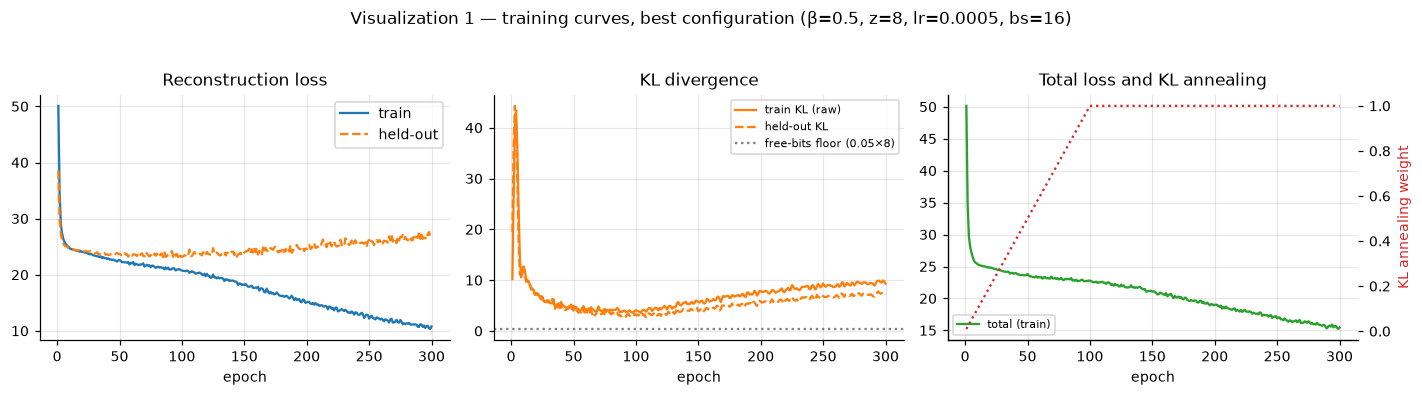

In [19]:
# ---- Visualization 1: training curves for the best configuration ----------------------
h = BEST_HIST
ep = np.arange(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(ep, h["reconstruction_loss"], label="train")
ax[0].plot(ep, h["val_reconstruction_loss"], label="held-out", ls="--")
ax[0].set_title("Reconstruction loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, h["kl_loss"], color="tab:orange", label="train KL (raw)")
ax[1].plot(ep, h["val_kl_loss"], color="tab:orange", ls="--", label="held-out KL")
ax[1].axhline(FREE_BITS * BEST_CFG["latent_dim"], color="gray", ls=":",
              label=f"free-bits floor ({FREE_BITS}×{BEST_CFG['latent_dim']})")
ax[1].set_title("KL divergence"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=7)
ax[2].plot(ep, h["loss"], color="tab:green", label="total (train)")
ax2 = ax[2].twinx(); ax2.plot(ep, h["kl_weight"], color="tab:red", ls=":", label="KL weight w(t)")
ax2.set_ylabel("KL annealing weight", color="tab:red"); ax2.grid(False)
ax[2].set_title("Total loss and KL annealing"); ax[2].set_xlabel("epoch"); ax[2].legend(loc="lower left", fontsize=7)
fig.suptitle(f"Visualization 1 — training curves, best configuration "
             f"(β={BEST_CFG['beta']}, z={BEST_CFG['latent_dim']}, lr={BEST_CFG['lr']:g}, bs={BEST_CFG['batch_size']})",
             y=1.04)
fig.tight_layout(); savefig(fig, "viz1_training_curves"); plt.show()

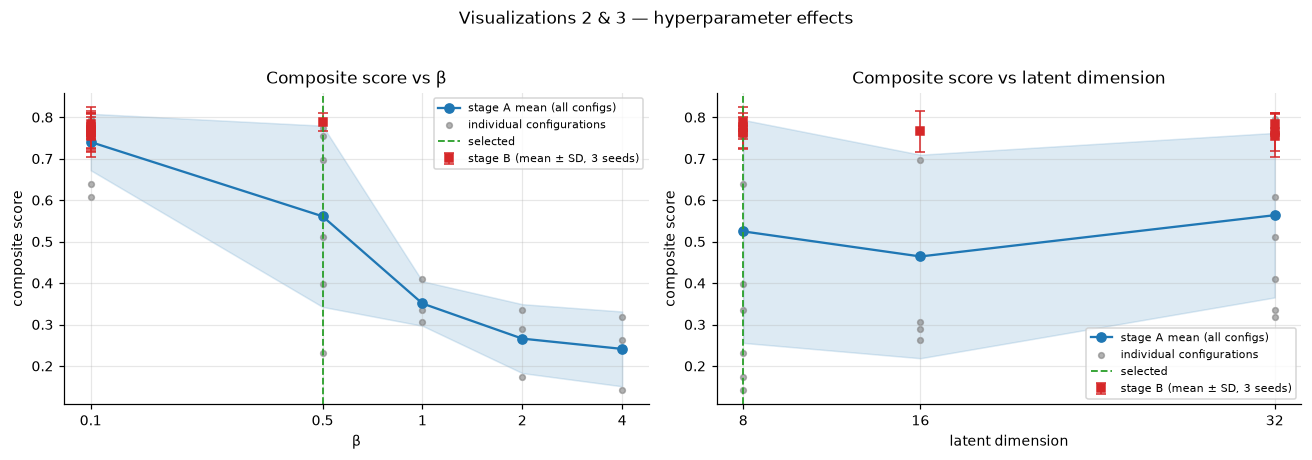

In [20]:
# ---- Visualizations 2 & 3: effect of beta and of latent dimension ---------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, param, lbl in zip(axes, ["beta", "latent_dim"], ["β", "latent dimension"]):
    gA = stage_a.groupby(param)["score"]
    xs = list(gA.groups.keys())
    ax.plot(xs, gA.mean().values, "o-", color="tab:blue", label="stage A mean (all configs)")
    ax.fill_between(xs, (gA.mean() - gA.std().fillna(0)).values,
                    (gA.mean() + gA.std().fillna(0)).values, alpha=0.15, color="tab:blue")
    ax.scatter(stage_a[param], stage_a["score"], s=14, color="tab:gray", alpha=0.6,
               label="individual configurations", zorder=1)
    if summary[param].nunique() > 0:
        ax.errorbar(summary[param], summary["score_mean"], yerr=summary["score_std"].fillna(0),
                    fmt="s", color="tab:red", ms=5, capsize=3, lw=1,
                    label=f"stage B (mean ± SD, {len(REPEAT_SEEDS)} seeds)")
    ax.axvline(BEST_CFG[param], color="tab:green", ls="--", lw=1.2, label="selected")
    ax.set_xlabel(lbl); ax.set_ylabel("composite score")
    ax.set_title(f"Composite score vs {lbl}")
    if param == "beta":
        ax.set_xscale("log"); ax.minorticks_off()
    ax.set_xticks(xs); ax.set_xticklabels([f"{x:g}" for x in xs])
    ax.legend(fontsize=7)
fig.suptitle("Visualizations 2 & 3 — hyperparameter effects", y=1.03)
fig.tight_layout(); savefig(fig, "viz23_hyperparameter_effects"); plt.show()

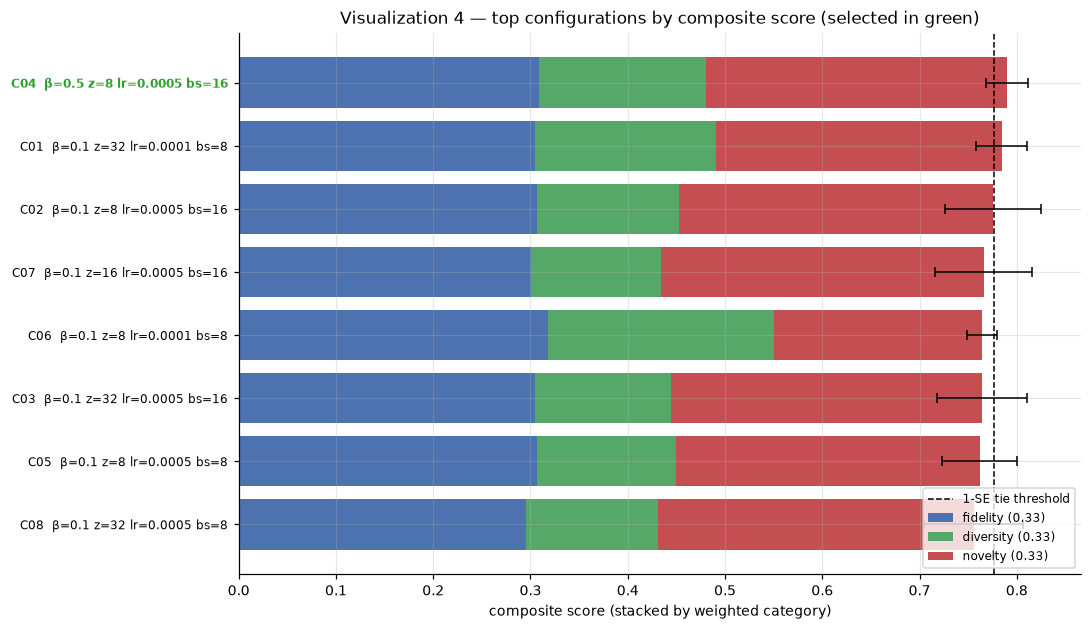

In [21]:
# ---- Visualization 4: configuration ranking ------------------------------------------
top = summary.head(min(10, len(summary))).iloc[::-1]
lbl = [f"{r.config_id}  β={r.beta} z={int(r.latent_dim)} lr={r.lr:g} bs={int(r.batch_size)}"
       for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(10, 0.45 * len(top) + 2.2))
y = np.arange(len(top))
left = np.zeros(len(top))
for comp, color in zip(["fidelity", "diversity", "novelty"], ["#4C72B0", "#55A868", "#C44E52"]):
    vals = top[f"{comp}_mean"].values * CATEGORY_WEIGHTS[comp]
    ax.barh(y, vals, left=left, color=color, label=f"{comp} ({CATEGORY_WEIGHTS[comp]:.2f})")
    left += vals
ax.errorbar(top["score_mean"], y, xerr=top["score_std"].fillna(0), fmt="none",
            ecolor="black", capsize=3, lw=1)
ax.axvline(SCORE_THRESH, color="black", ls="--", lw=1,
           label="1-SE tie threshold" if ONE_SE_RULE else None)
ax.set_yticks(y); ax.set_yticklabels(lbl, fontsize=8)
ax.set_xlabel("composite score (stacked by weighted category)")
sel = list(top.config_id).index(CHOSEN.config_id) if CHOSEN.config_id in list(top.config_id) else None
if sel is not None:
    ax.get_yticklabels()[sel].set_color("tab:green"); ax.get_yticklabels()[sel].set_fontweight("bold")
ax.set_title("Visualization 4 — top configurations by composite score (selected in green)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); savefig(fig, "viz4_configuration_ranking"); plt.show()

representative channels: {'IMU ch0': 0, 'IMU ch1': 1, 'IMU ch2': 2, 'Radar ch373 (var rank 1)': 373, 'Radar ch46 (var rank 284)': 46, 'Radar ch668 (var rank 568)': 668}


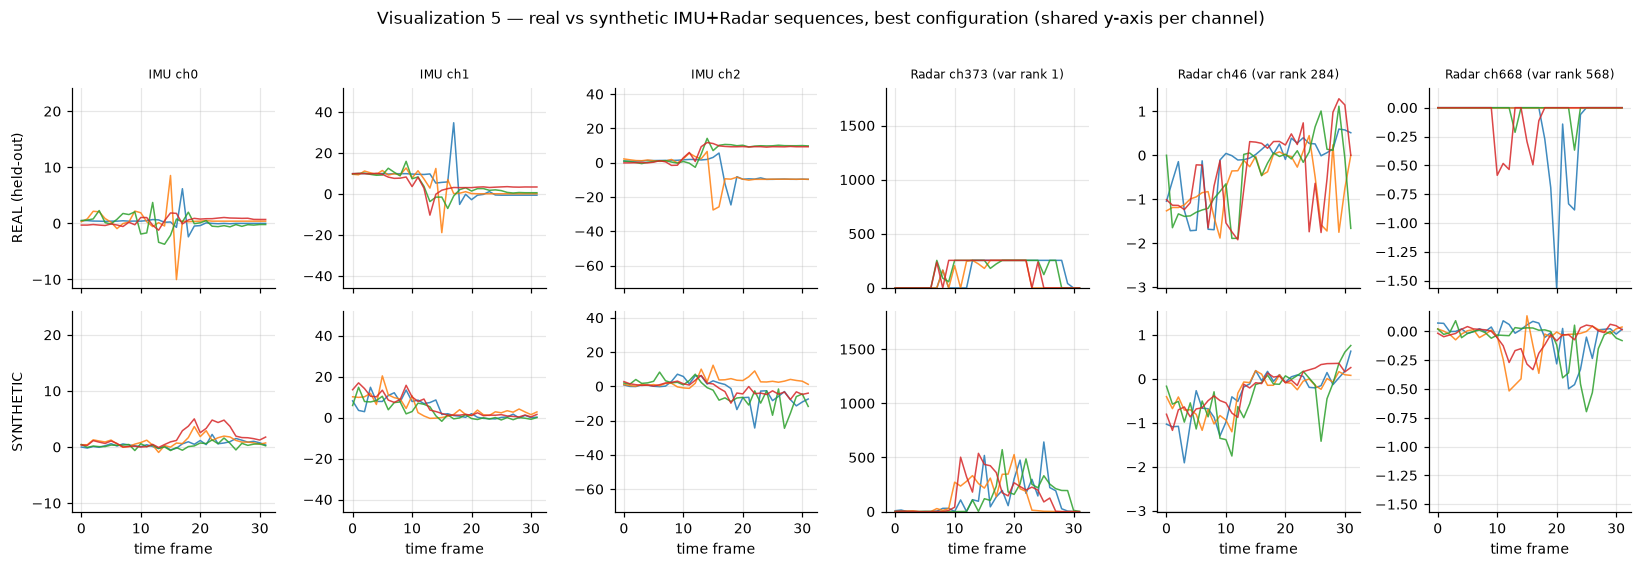

In [22]:
# ---- representative channel selection -------------------------------------------------
# 1137 dimensions cannot be plotted at once. Representative set = the IMU accelerometer channels
# (the first channels of the concatenated representation) plus the highest-variance radar bins.
N_IMU = min(3, N_FEATURES)
imu_ch = list(range(N_IMU))
rad_var   = X_raw[:, :, N_IMU:].reshape(-1, N_FEATURES - N_IMU).var(axis=0)
rad_order = np.argsort(rad_var)[::-1]                     # most variable radar bin first
# spread the picks across the variance ranking instead of taking three adjacent hot pixels
picks    = [0, len(rad_order) // 4, len(rad_order) // 2]
rad_ch    = [int(N_IMU + rad_order[p]) for p in picks]
REPR_CHANNELS = imu_ch + rad_ch
REPR_LABELS   = [f"IMU ch{c}" for c in imu_ch] + \
                [f"Radar ch{c} (var rank {p+1})" for c, p in zip(rad_ch, picks)]
print("representative channels:", dict(zip(REPR_LABELS, REPR_CHANNELS)))

# ---- Visualization 5: real vs synthetic sequences ------------------------------------
rng_v = np.random.default_rng(BASE_SEED)
r_idx = rng_v.choice(len(X_VAL_RAW), size=min(4, len(X_VAL_RAW)), replace=False)
s_idx = rng_v.choice(len(BEST_SYNTH), size=4, replace=False)
fig, axes = plt.subplots(2, len(REPR_CHANNELS), figsize=(2.5 * len(REPR_CHANNELS), 5), sharex=True)
for j, (c, name) in enumerate(zip(REPR_CHANNELS, REPR_LABELS)):
    for i in r_idx: axes[0, j].plot(X_VAL_RAW[i, :, c], lw=1, alpha=0.85)
    for i in s_idx: axes[1, j].plot(BEST_SYNTH[i, :, c], lw=1, alpha=0.85, ls="-")
    axes[0, j].set_title(name, fontsize=8)
    axes[1, j].set_xlabel("time frame")
    lo = min(X_VAL_RAW[:, :, c].min(), BEST_SYNTH[:, :, c].min())
    hi = max(X_VAL_RAW[:, :, c].max(), BEST_SYNTH[:, :, c].max())
    for row in (0, 1): axes[row, j].set_ylim(lo, hi)
axes[0, 0].set_ylabel("REAL (held-out)"); axes[1, 0].set_ylabel("SYNTHETIC")
fig.suptitle("Visualization 5 — real vs synthetic IMU+Radar sequences, best configuration "
             "(shared y-axis per channel)", y=1.02)
fig.tight_layout(); savefig(fig, "viz5_real_vs_synthetic_sequences"); plt.show()

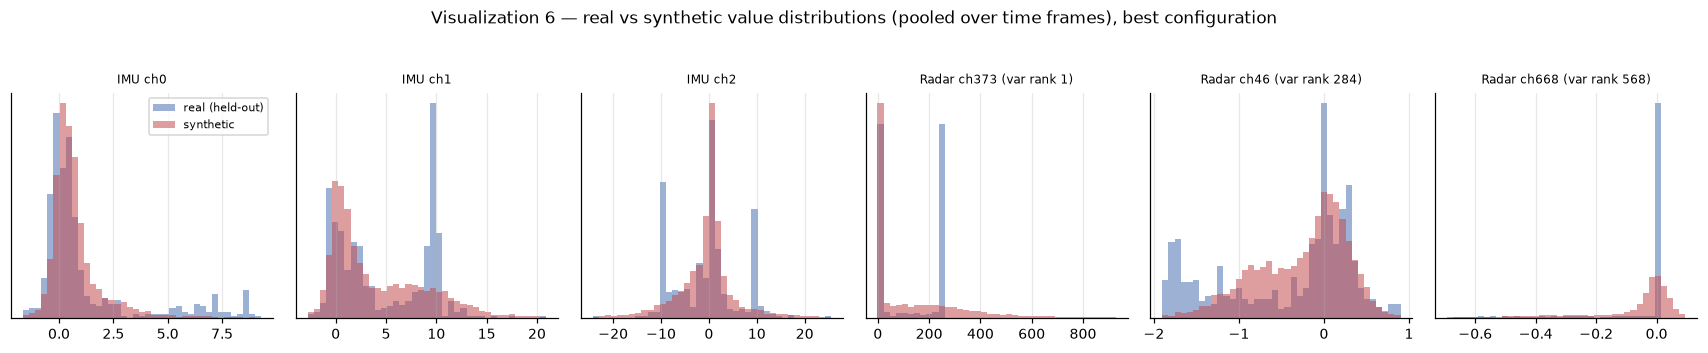

In [23]:
# ---- Visualization 6: distribution comparison ----------------------------------------
fig, axes = plt.subplots(1, len(REPR_CHANNELS), figsize=(2.6 * len(REPR_CHANNELS), 3.0))
for ax, c, name in zip(np.atleast_1d(axes), REPR_CHANNELS, REPR_LABELS):
    r = X_VAL_RAW[:, :, c].ravel(); s = BEST_SYNTH[:, :, c].ravel()
    lo, hi = np.percentile(np.concatenate([r, s]), [0.5, 99.5])
    bins = np.linspace(lo, hi, 40)
    ax.hist(r, bins=bins, density=True, alpha=0.55, label="real (held-out)", color="#4C72B0")
    ax.hist(s, bins=bins, density=True, alpha=0.55, label="synthetic", color="#C44E52")
    ax.set_title(name, fontsize=8); ax.set_yticks([])
np.atleast_1d(axes)[0].legend(fontsize=7)
fig.suptitle("Visualization 6 — real vs synthetic value distributions "
             "(pooled over time frames), best configuration", y=1.05)
fig.tight_layout(); savefig(fig, "viz6_distribution_comparison"); plt.show()

# Recommended β-VAE Configuration

The cell below builds the justification **from the computed results**, not from a template: it
checks fidelity, diversity, novelty, seed-to-seed stability, overfitting/memorisation, whether the
latent dimension is doing any work, and how much reconstruction quality β has cost. Where the
evidence is unflattering it says so.

In [24]:
def quart(series, value, higher_better):
    """Where a value sits within the repeated configurations (0 = worst, 1 = best)."""
    v = series.dropna().to_numpy(dtype=float)
    if len(v) < 2: return 0.5
    r = (v <= value).mean() if higher_better else (v >= value).mean()
    return float(r)

c = CHOSEN
lines = []
lines.append(f"## Selected configuration: **{c.config_id}** — "
             f"β = {BEST_CFG['beta']}, latent dim = {BEST_CFG['latent_dim']}, "
             f"lr = {BEST_CFG['lr']:g}, batch size = {BEST_CFG['batch_size']}")
lines.append(f"Composite score **{c.score_mean:.4f} ± {0.0 if pd.isna(c.score_std) else c.score_std:.4f}** "
             f"over {int(c.n_seeds)} seeds "
             f"(fidelity {c.fidelity_mean:.3f}, diversity {c.diversity_mean:.3f}, "
             f"novelty {c.novelty_mean:.3f}).")

# --- fidelity ---
f_rank = quart(summary["fidelity_mean"], c.fidelity_mean, True)
lines.append(f"\n**Fidelity.** MMD {c.mmd_mean:.4f} (grid best {summary.mmd_mean.min():.4f}), "
             f"Wasserstein {c.wasserstein_mean:.4f}, Hellinger {c.hellinger_mean:.4f}, "
             f"correlation difference {c.corr_diff_mean:.4f}. This configuration sits in the "
             f"{f_rank*100:.0f}% mark of the repeated configurations on fidelity. "
             + ("Fidelity is a genuine strength here." if f_rank >= 0.6 else
                "Fidelity is mid-pack — it is carried by the other two categories, which is acceptable "
                "only because the distributional metrics are computed against just "
                f"{len(VAL_IDX)} held-out samples and are correspondingly noisy."))

# --- diversity ---
lines.append(f"\n**Diversity.** Coverage {c.coverage_mean:.3f} (fraction of held-out real samples "
             f"with a synthetic neighbour inside their k={PRDC_K} radius), density {c.density_mean:.3f}, "
             f"variance difference {c.var_diff_mean:.3f}. "
             + ("Coverage is high, so the generator is not collapsing onto a subset of the real "
                "manifold." if c.coverage_mean >= 0.6 else
                "Coverage is moderate: part of the real manifold is still not being generated, which "
                "the later sample-size study may partly compensate for by generating more samples."))

# --- novelty ---
memo_txt = (f"The memorisation diagnostic is {c.memo_rate_mean:.3f}" +
            (" — a substantial share of synthetic samples are near-copies of real ones, which for "
             "aggregated-posterior sampling is a known risk and should be re-checked downstream."
             if c.memo_rate_mean > 0.25 else
             " — near-duplication of real samples is not a dominant failure mode here."))
lines.append(f"\n**Novelty.** NN ratio {c.nn_ratio_mean:.3f} "
             f"(synthetic→real nearest-neighbour distance divided by the real→real one; "
             f"1.0 means synthetic samples are as far from real samples as real samples are from each "
             f"other, <<1 means copying). {memo_txt}")

# --- stability ---
cv = (0.0 if pd.isna(c.score_std) or c.score_mean == 0 else c.score_std / abs(c.score_mean))
stab_rank = summary.assign(cv=summary.score_std.fillna(0) / summary.score_mean.abs())
lines.append(f"\n**Stability across repetitions.** Score SD {0.0 if pd.isna(c.score_std) else c.score_std:.4f} "
             f"(coefficient of variation {cv*100:.1f}%), versus a median of "
             f"{stab_rank.cv.median()*100:.1f}% across the repeated configurations. "
             + ("This is one of the more reproducible configurations." if cv <= stab_rank.cv.median()
                else "This configuration is noisier than average across seeds; treat its exact rank "
                     "position as provisional."))

# --- overfitting ---
rel = (c.val_recon_loss_mean - c.recon_loss_mean) / max(abs(c.recon_loss_mean), 1e-9)
mmd_rel = c.mmd_train_gap_mean / max(abs(c.mmd_mean), 1e-9)
recon_txt = ("the model reconstructs unseen real samples about as well as its own training samples"
             if rel < 0.35 else
             f"held-out reconstruction is {rel*100:.0f}% worse than training reconstruction, which with "
             f"{N_FEATURES} features and {len(TRAIN_IDX)} training samples is a real overfitting signal")
mmd_txt = ("synthetic data is no closer to the training samples than to the held-out ones, so the "
           "generator is not simply replaying what it was trained on"
           if mmd_rel > -0.25 else
           f"synthetic data is {abs(mmd_rel)*100:.0f}% closer (in MMD) to the training samples than to "
           "the held-out ones — the generator leans on the specific samples it saw, so the downstream "
           "evaluation should keep using a held-out reference rather than the full real set")
flagged = bool(c.get("overfit_flag_any", False))
if flagged:
    lines.append(f"\n**Overfit flag TRIPPED.** At least one seed of this configuration crossed the "
                 f"`OVERFIT_RATIO_MAX = {OVERFIT_RATIO_MAX}` line (mean ratio "
                 f"{c.overfit_ratio_mean:.2f}). The configuration still won the composite score, "
                 f"but the reconstruction gap is a real diagnostic signal — treat the intrinsic "
                 f"metrics with extra caution and rely on the downstream utility check to confirm.")
lines.append(f"\n**Overfitting and memorisation.** Held-out reconstruction loss {c.val_recon_loss_mean:.3f} "
             f"vs training {c.recon_loss_mean:.3f} ({rel*100:+.1f}%): {recon_txt}. "
             f"The train-vs-held-out MMD gap is {c.mmd_train_gap_mean:+.4f}: {mmd_txt}.")

# --- latent size ---
au = c.active_units_mean
lines.append(f"\n**Is the latent dimension larger than necessary?** {au:.1f} of "
             f"{BEST_CFG['latent_dim']} latent units are active (posterior mean variance > 1e-2). "
             + (f"Essentially all units carry signal, so {BEST_CFG['latent_dim']} is not oversized."
                if au >= 0.8 * BEST_CFG["latent_dim"] else
                f"Only {au/BEST_CFG['latent_dim']*100:.0f}% of the capacity is used — a smaller latent "
                "dimension would likely perform the same with fewer parameters, which is why the "
                "simplicity rule prefers small latent dimensions among tied configurations."))

# --- beta cost ---
best_recon = summary.recon_loss_mean.min()
degr = (c.recon_loss_mean - best_recon) / max(abs(best_recon), 1e-9)
lines.append(f"\n**Does β degrade reconstruction too much?** Reconstruction loss {c.recon_loss_mean:.3f} "
             f"vs the best in the repeated set {best_recon:.3f} ({degr*100:+.1f}%). "
             + ("β is not buying regularisation at an unacceptable reconstruction cost."
                if degr < 0.25 else
                "β costs a meaningful amount of reconstruction accuracy; it is retained only because the "
                "diversity and novelty gains outweigh it in the composite score."))

# --- robustness vs single winner ---
if len(TIED) > 1:
    others = ", ".join(f"{r.config_id} (β={r.beta}, z={int(r.latent_dim)}, {r.score_mean:.4f})"
                       for r in TIED.iloc[1:].itertuples())
    lines.append(f"\n**Robust, not merely the numerical winner.** {len(TIED)} configurations are within "
                 f"one standard error of the leader ({SCORE_THRESH:.4f}): {others}. "
                 f"The differences between them are inside seed noise, so the simpler configuration "
                 f"was chosen rather than the single highest number.")
    if CHOSEN.config_id != LEADER.config_id:
        lines.append(f"The raw leader was **{LEADER.config_id}** "
                     f"(β={LEADER.beta}, z={int(LEADER.latent_dim)}, score {LEADER.score_mean:.4f}); "
                     f"**{CHOSEN.config_id}** was preferred because it is statistically tied with it and "
                     f"less complex. If you would rather report the maximiser, both are defensible — "
                     f"state the rule you used.")
else:
    lines.append(f"\n**Robust, not merely the numerical winner.** No other configuration reaches the "
                 f"1-SE threshold ({SCORE_THRESH:.4f}), so the leader wins outright rather than by a "
                 f"margin inside seed noise.")

lines.append(f"\n**Caveats worth carrying forward.** The reference set is {len(VAL_IDX)} held-out real "
             f"samples; coverage and density are noisy at that size, and the Gaussian Hellinger "
             f"distance requires covariance shrinkage. The selection is therefore a *ranking* over "
             f"configurations, not an absolute quality certificate — the downstream sample-size study "
             f"and post-evaluation remain the real test.")

JUSTIFICATION = "\n".join(lines)
display(Markdown(JUSTIFICATION))

## Selected configuration: **C04** — β = 0.5, latent dim = 8, lr = 0.0005, batch size = 16
Composite score **0.7895 ± 0.0216** over 3 seeds (fidelity 0.926, diversity 0.516, novelty 0.927).

**Fidelity.** MMD 0.0303 (grid best 0.0200), Wasserstein 0.3061, Hellinger 0.1828, correlation difference 0.4300. This configuration sits in the 88% mark of the repeated configurations on fidelity. Fidelity is a genuine strength here.

**Diversity.** Coverage 1.000 (fraction of held-out real samples with a synthetic neighbour inside their k=5 radius), density 0.748, variance difference 0.614. Coverage is high, so the generator is not collapsing onto a subset of the real manifold.

**Novelty.** NN ratio 1.157 (synthetic→real nearest-neighbour distance divided by the real→real one; 1.0 means synthetic samples are as far from real samples as real samples are from each other, <<1 means copying). The memorisation diagnostic is 0.153 — near-duplication of real samples is not a dominant failure mode here.

**Stability across repetitions.** Score SD 0.0216 (coefficient of variation 2.7%), versus a median of 5.5% across the repeated configurations. This is one of the more reproducible configurations.

**Overfitting and memorisation.** Held-out reconstruction loss 27.092 vs training 10.764 (+151.7%): held-out reconstruction is 152% worse than training reconstruction, which with 1137 features and 79 training samples is a real overfitting signal. The train-vs-held-out MMD gap is -0.0123: synthetic data is 40% closer (in MMD) to the training samples than to the held-out ones — the generator leans on the specific samples it saw, so the downstream evaluation should keep using a held-out reference rather than the full real set.

**Is the latent dimension larger than necessary?** 8.0 of 8 latent units are active (posterior mean variance > 1e-2). Essentially all units carry signal, so 8 is not oversized.

**Does β degrade reconstruction too much?** Reconstruction loss 10.764 vs the best in the repeated set 3.910 (+175.3%). β costs a meaningful amount of reconstruction accuracy; it is retained only because the diversity and novelty gains outweigh it in the composite score.

**Robust, not merely the numerical winner.** 2 configurations are within one standard error of the leader (0.7770): C01 (β=0.1, z=32, 0.7843). The differences between them are inside seed noise, so the simpler configuration was chosen rather than the single highest number.

**Caveats worth carrying forward.** The reference set is 20 held-out real samples; coverage and density are noisy at that size, and the Gaussian Hellinger distance requires covariance shrinkage. The selection is therefore a *ranking* over configurations, not an absolute quality certificate — the downstream sample-size study and post-evaluation remain the real test.

## §17. Save results

Everything is written under the timestamped run directory created in §2 — no existing project file
is read-modify-written.

In [25]:
all_runs = pd.concat([stage_a, stage_b[stage_b.stage == "B"]], ignore_index=True, sort=False)
all_runs["config_id"] = all_runs["config_key"].map(CONFIG_ID)

_TAG      = MODALITY.lower()          # e.g. "imu_radar"
p_results = RUN_DIR / f"vae_grid_search_results_{_TAG}.csv"
p_top     = RUN_DIR / f"vae_top_configurations_{_TAG}.csv"
p_best    = RUN_DIR / f"vae_best_config_{_TAG}.json"
p_summary = RUN_DIR / f"vae_selection_summary_{_TAG}.json"
p_report  = RUN_DIR / f"vae_selection_report_{_TAG}.md"
p_enc     = RUN_DIR / f"vae_best_model_encoder_{_TAG}.keras"
p_dec     = RUN_DIR / f"vae_best_model_decoder_{_TAG}.keras"
p_encw    = RUN_DIR / f"vae_best_model_encoder_{_TAG}.weights.h5"
p_decw    = RUN_DIR / f"vae_best_model_decoder_{_TAG}.weights.h5"

all_runs.to_csv(p_results, index=False)
summary.to_csv(p_top, index=False)
BEST_MODEL.encoder.save(p_enc); BEST_MODEL.decoder.save(p_dec)
BEST_MODEL.encoder.save_weights(p_encw); BEST_MODEL.decoder.save_weights(p_decw)

best_payload = {
    "modality": MODALITY,
    "modality_label": MODALITY_LABEL,
    "expected_shape": list(EXPECTED_SHAPE),
    "imu_features": EXPECTED_IMU_FEATURES,
    "radar_features": EXPECTED_RADAR_FEATURES,
    "selected_at": datetime.now().isoformat(timespec="seconds"),
    "config_id": str(CHOSEN.config_id),
    "overfit_flag_any": bool(CHOSEN.get("overfit_flag_any", False)),
    "overfit_ratio_mean": float(CHOSEN.overfit_ratio_mean),
    "hyperparameters": BEST_CFG,
    "fixed_training_settings": {
        "epochs": EPOCHS, "free_bits": FREE_BITS, "anneal_epochs": ANNEAL_EPOCHS,
        "sampler": SAMPLER, "enc_filters": list(ENC_FILTERS), "dec_filters": list(DEC_FILTERS),
    },
    "preprocessing": {
        "signed_log": USE_SIGNED_LOG, "drop_constant": DROP_CONSTANT, "use_pca": USE_PCA,
        "pca_dims": PCA_DIMS, "effective_dim": int(PREP_DIM),
        "explained_variance_ratio": float(PREP.explained_), "minmax_range": [0, 1],
    },
    "data": {"path": str(data_path), "shape": list(X_raw.shape),
             "train_idx": TRAIN_IDX.tolist(), "val_idx": VAL_IDX.tolist(),
             "split_seed": SPLIT_SEED, "val_fraction": VAL_FRACTION},
    "evaluation": {"n_synth_eval": N_SYNTH_EVAL, "embed_dims": int(EVAL_CTX["k"]),
                   "prdc_k": PRDC_K, "seeds": REPEAT_SEEDS,
                   "category_weights": CATEGORY_WEIGHTS,
                   "grid_mode": GRID_MODE_USED, "n_configurations": int(stage_a.shape[0])},
    "metrics_mean": {m: float(CHOSEN[f"{m}_mean"]) for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS},
    "metrics_std":  {m: (None if pd.isna(CHOSEN[f"{m}_std"]) else float(CHOSEN[f"{m}_std"]))
                     for m in list(METRIC_DIRECTION) + DIAGNOSTIC_METRICS},
    "composite_score": {"mean": float(CHOSEN.score_mean),
                        "std": (None if pd.isna(CHOSEN.score_std) else float(CHOSEN.score_std)),
                        "fidelity": float(CHOSEN.fidelity_mean),
                        "diversity": float(CHOSEN.diversity_mean),
                        "novelty": float(CHOSEN.novelty_mean),
                        "one_se_threshold": SCORE_THRESH,
                        "raw_leader": str(LEADER.config_id)},
    "next_pipeline_step": "1x-10x synthetic sample-size selection + pre-evaluation",
}
with open(p_best, "w") as f: json.dump(best_payload, f, indent=2)
with open(p_summary, "w") as f: json.dump(best_payload, f, indent=2)
with open(p_report, "w") as f:
    f.write(f"# β-VAE hyperparameter selection — {MODALITY} ({MODALITY_LABEL})"
            f" — run {RUN_ID}\n\n{JUSTIFICATION}\n")
(RUN_DIR / "_partial_results.csv").unlink(missing_ok=True)

print("Saved:")
for p in [p_results, p_top, p_best, p_summary, p_report, p_enc, p_dec, p_encw, p_decw]:
    print(f"   {p.relative_to(OUTPUT_ROOT.parent)}  ({p.stat().st_size/1024:.1f} KB)")
print(f"   {FIG_DIR.relative_to(OUTPUT_ROOT.parent)}/  "
      f"({len(list(FIG_DIR.glob('*.png')))} figures)")

Saved:
   vae_grid_search_imu_radar\run_20260914_221918\vae_grid_search_results_imu_radar.csv  (21.9 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_top_configurations_imu_radar.csv  (6.7 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_best_config_imu_radar.json  (3.8 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_selection_summary_imu_radar.json  (3.8 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_selection_report_imu_radar.md  (2.9 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_best_model_encoder_imu_radar.keras  (227.9 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_best_model_decoder_imu_radar.keras  (394.2 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_best_model_encoder_imu_radar.weights.h5  (220.1 KB)
   vae_grid_search_imu_radar\run_20260914_221918\vae_best_model_decoder_imu_radar.weights.h5  (386.1 KB)
   vae_grid_search_imu_radar\run_20260914_221918\figures/  (5 figures)


# Final Recommendation

In [26]:
overfit_note = ("**Overfit note:** the winner tripped the `OVERFIT_RATIO_MAX` line on at least one seed (mean ratio %.2f)." % float(CHOSEN.overfit_ratio_mean)) if bool(CHOSEN.get("overfit_flag_any", False)) else ""
rec = f"""
**Modality:** {MODALITY} ({MODALITY_LABEL}) — expected raw shape {EXPECTED_SHAPE} ({EXPECTED_IMU_FEATURES} IMU + {EXPECTED_RADAR_FEATURES} Radar).

**Selected β-VAE configuration** (configuration {CHOSEN.config_id}, chosen from
{stage_a.shape[0]} grid configurations, {int(CHOSEN.n_seeds)} evaluation seeds on the winner):

* **β = {BEST_CFG['beta']}**
* **latent dimension = {BEST_CFG['latent_dim']}**
* **learning rate = {BEST_CFG['lr']:g}**
* **batch size = {BEST_CFG['batch_size']}**

Held fixed alongside them: {EPOCHS} epochs, free bits {FREE_BITS}, KL annealing over
{ANNEAL_EPOCHS} epochs, `{SAMPLER}` latent sampling, and the existing reversible
signed-log → drop-constant → PCA({PREP_DIM}) → MinMax representation.

**Reason for selection:** highest composite score
({CHOSEN.score_mean:.4f} ± {0.0 if pd.isna(CHOSEN.score_std) else CHOSEN.score_std:.4f}) under an
equal-weight fidelity / diversity / novelty criterion — fidelity {CHOSEN.fidelity_mean:.3f},
diversity {CHOSEN.diversity_mean:.3f}, novelty {CHOSEN.novelty_mean:.3f} — and, where configurations
were statistically tied within one standard error, the simpler one was preferred. See §16 for the
full reasoning including stability, overfitting and latent-utilisation checks.

**Next pipeline step:** use this configuration in the existing 1×–10× synthetic sample-size
selection and pre-evaluation pipeline (5 repetitions per sample size → mean metrics → best sample
size → final generation → post-evaluation). Load it with:

```python
import json
best = json.load(open(r"{p_best}"))["hyperparameters"]
```

{overfit_note}

*This notebook selected hyperparameters only. It did not choose a synthetic sample size, did not
generate the final synthetic dataset, and did not modify any existing project file.*
"""
display(Markdown(rec))


**Modality:** IMU_RADAR (IMU + Radar) — expected raw shape (99, 32, 1137) (3 IMU + 1134 Radar).

**Selected β-VAE configuration** (configuration C04, chosen from
24 grid configurations, 3 evaluation seeds on the winner):

* **β = 0.5**
* **latent dimension = 8**
* **learning rate = 0.0005**
* **batch size = 16**

Held fixed alongside them: 300 epochs, free bits 0.05, KL annealing over
100 epochs, `aggregated` latent sampling, and the existing reversible
signed-log → drop-constant → PCA(32) → MinMax representation.

**Reason for selection:** highest composite score
(0.7895 ± 0.0216) under an
equal-weight fidelity / diversity / novelty criterion — fidelity 0.926,
diversity 0.516, novelty 0.927 — and, where configurations
were statistically tied within one standard error, the simpler one was preferred. See §16 for the
full reasoning including stability, overfitting and latent-utilisation checks.

**Next pipeline step:** use this configuration in the existing 1×–10× synthetic sample-size
selection and pre-evaluation pipeline (5 repetitions per sample size → mean metrics → best sample
size → final generation → post-evaluation). Load it with:

```python
import json
best = json.load(open(r"c:\Users\mabideen\Downloads\Data_Augmentation\DL_Grid_Search\vae_grid_search_imu_radar\run_20260914_221918\vae_best_config_imu_radar.json"))["hyperparameters"]
```



*This notebook selected hyperparameters only. It did not choose a synthetic sample size, did not
generate the final synthetic dataset, and did not modify any existing project file.*
